# **☆. Open API download**

In [1]:
import requests
import json
import pandas as pd

## 식중독 원인물질별 현황

In [2]:
# API 키와 기본 URL 설정
api = "ca73f2febeba4a91a37a"
base_url = "http://openapi.foodsafetykorea.go.kr/api/"+api+'/I2850/json/'

In [3]:
# 데이터를 저장할 리스트
all_data = []

# 데이터 호출 (최대 500번, 1000개씩)
for i in range(500):
    start = i * 1000 + 1  # 시작 위치
    end = (i + 1) * 1000  # 끝 위치
    
    # URL 구성
    url = base_url + str(start) + '/' + str(end)
    
    # API 호출
    response = requests.get(url)
    
    # 응답이 성공적인지 확인
    if response.status_code == 200:
        try:
            # JSON 응답을 파싱하여 데이터 추출
            data = response.json()
            row_data = data['I2850']['row']
            all_data.extend(row_data)  # 데이터를 리스트에 추가
        except KeyError:
            print(f"데이터가 더 이상 없습니다. 총 {i}번 호출 완료.")
            break
    else:
        print(f"API 호출에 실패했습니다. 상태 코드: {response.status_code}")
        break

데이터가 더 이상 없습니다. 총 2번 호출 완료.


In [4]:
# 전체 데이터를 DataFrame으로 변환
df = pd.DataFrame(all_data)

# 데이터 확인
print(df.head())

  OCCRNC_YEAR OCCRNC_MM PATNT_CNT OCCRNC_CNT OCCRNC_VIRS
0        2024        09       528         33         진행중
1        2024        09       110          1     황색포도상구균
2        2024        08        43          2      노로바이러스
3        2024        08        13          2      병원성대장균
4        2024        08        38          3          불명


In [ ]:
# df.to_csv('OPENAPI_식중독 원인물질별 현황.csv', index=False,encoding='utf-8')

## 식중독 지역별 현황

In [6]:
# API 키와 기본 URL 설정
base_url3 = "http://openapi.foodsafetykorea.go.kr/api/"+api+'/I2848/json/'

In [7]:
# 데이터를 저장할 리스트
all_data3 = []

# 데이터 호출 (최대 500번, 1000개씩)
for i in range(500):
    start = i * 1000 + 1  # 시작 위치
    end = (i + 1) * 1000  # 끝 위치
    
    # URL 구성
    url3 = base_url3 + str(start) + '/' + str(end)
    
    # API 호출
    response3 = requests.get(url3)
    
    # 응답이 성공적인지 확인
    if response3.status_code == 200:
        try:
            # JSON 응답을 파싱하여 데이터 추출
            data3 = response3.json()
            row_data3 = data3['I2848']['row']
            all_data3.extend(row_data3)  # 데이터를 리스트에 추가
        except KeyError:
            print(f"데이터가 더 이상 없습니다. 총 {i}번 호출 완료.")
            break
    else:
        print(f"API 호출에 실패했습니다. 상태 코드: {response3.status_code}")
        break

데이터가 더 이상 없습니다. 총 3번 호출 완료.


In [8]:
# 전체 데이터를 DataFrame으로 변환
df3 = pd.DataFrame(all_data3)

# 데이터 확인
print(df3.head())

  OCCRNC_YEAR OCCRNC_MM PATNT_CNT OCCRNC_CNT OCCRNC_AREA
0        2024        09        14          2          서울
1        2024        09       208          3          강원
2        2024        09         2          1          충북
3        2024        09         4          1          충남
4        2024        09         2          1          전북


In [ ]:
# df3.to_csv('OPENAPI_식중독 지역별 현황.csv', index=False,encoding='utf-8')

# **Ⅰ. 패키지 관리**

In [10]:
# 데이터 처리 및 전처리
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler

# 통계분석 및 진단
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 데이터 분할 및 모델 선택
from pycaret.classification import setup, compare_models, pull, get_config
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict

# 모델링 및 알고리즘
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, log_evaluation, early_stopping

# 모델 성능평가
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, roc_curve, auc

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.font_manager as fm
from pandas.plotting import scatter_matrix

# 파일 입출력 및 시스템 설정
import os
import joblib
import warnings
warnings.filterwarnings('ignore')


# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' if 'Malgun Gothic' in [f.name for f in fm.fontManager.ttflist] else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

In [11]:
import os
os.chdir('D:/foodpoision_project/data')

# **Ⅱ. Master Table 제작**

## **1. 지역별 Master Table**

### 1. 식중독 지역별 현황

In [12]:
mfds_region_df = pd.read_csv('OpenAPI_식중독 지역별 현황.csv')
data = []

# 지역 정의
areas = ['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']

# 발생 지역 순서 반복문
for year in range(2023, 2001, -1):
    for area in areas:
        for month in range(12, 0, -1):
            data.append([year, month, area])

master_format_ed_df = pd.DataFrame(data, columns=["OCCRNC_YEAR", "OCCRNC_MM", "OCCRNC_REGN"])

In [13]:
# Master_format 에 Year, Month, Region 기준으로 병합
merged_df1 = pd.merge(
    master_format_ed_df,
    mfds_region_df[['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_AREA','OCCRNC_CNT','PATNT_CNT']],
    left_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN'],
    right_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_AREA'],
    how='left'
)

# 'OCCRNC_AREA' 컬럼 삭제
merged_df1 = merged_df1.drop(columns=['OCCRNC_AREA'])

# 'OCCRNC_CNT', 'PATNT_CNT' 에서 결측치 (식중독 미발생 케이스) 0으로 치환
merged_df1 = merged_df1.fillna(0)

# 식중독 발생 유무를 나타내는 'OCCRNC_IND' (Occurrence Indicator) 컬럼 추가 (발생했을 경우 1, 미발생의 경우 0)
merged_df1['OCCRNC_IND'] = merged_df1['OCCRNC_CNT'].apply(lambda x: 0 if x == 0 else 1)

### 2. Golden Holiday 병합

In [14]:
merged_df2 = merged_df1.copy()
hol_df = pd.read_csv('Regional_golden_holidays_2002_2023.csv')
# hol_df 에서 년/월 기준으로 그룹화 및 'HOL_DUR' 값 합 계산
hol_grouped = hol_df.groupby(['HOL_YEAR', "HOL_MM"]).agg({'HOL_DUR': 'sum'})

# Holiday 관련 컬럼 추가
# HOL_IND : 황금연휴의 유무를 나타내는 컬럼 (Holiday Indicator) 추가
# HOL_DUR : 황금연휴의 기간을 나타내는 컬럼 (Holiday Duration) 추가
merged_df2['HOL_IND'] = 0
merged_df2['HOL_DUR'] = 0

# HOL_IND : 특정 년/월에 황금연휴가 존재할 경우 1, 없을 경우 0 으로 표기
# HOL_DUR : 특정 년/월에 존재하는 모든 황금연휴의 총 일수
for idx, row in merged_df2.iterrows():
    year = row['OCCRNC_YEAR']
    month = row['OCCRNC_MM']
    if (year, month) in hol_grouped.index:
        merged_df2.at[idx, 'HOL_IND'] = 1
        merged_df2.at[idx, 'HOL_DUR'] = hol_grouped.loc[(year, month), 'HOL_DUR']

### 3. CPI 병합

In [15]:
merged_df3 = merged_df2.copy()
CPI_df = pd.read_csv('Regional_CPI_2002_2022.csv')

# merged_df3와 CPI_df를 'OCCRNC_YEAR'와 'CPI_YEAR', 'OCCRNC_MM'와 'CPI_MM', 'OCCRNC_REGN'과 'CPI_REGN' 기준으로 병합
merged_df3 = pd.merge(
    merged_df3,
    CPI_df,
    left_on=['OCCRNC_YEAR', 'OCCRNC_MM', 'OCCRNC_REGN'],
    right_on=['CPI_YEAR', 'CPI_MM', 'CPI_REGN'],
    how='left'
)

# 필요 없는 'CPI_YEAR', 'CPI_MM', 'CPI_REGN' 컬럼 제거
merged_df3 = merged_df3.drop(columns=['CPI_YEAR', 'CPI_MM', 'CPI_REGN'])

### 4. 기후 병합

In [16]:
merged_df4 = merged_df3.copy()
weather_df = pd.read_csv('Regional_weather_2002_2024.csv')

# merged_df4 와 weather_df를 'OCCRNC_YEAR'와 'WTHR_YEAR', 'OCCRNC_MM'와 'WTHR_MM', 'OCCRNC_REGN'과 'WTHR_REGN' 기준으로 병합
merged_df4 = pd.merge(
    merged_df4,
    weather_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN'],
    right_on=['WTHR_YEAR','WTHR_MM','WTHR_REGN'],
    how='left'
)

# 필요 없는 'WTHR_YEAR','WTHR_MM','WTHR_REGN' 컬럼 제거
merged_df4 = merged_df4.drop(columns=['WTHR_YEAR','WTHR_MM','WTHR_REGN'])

### 5. 축제 병합

In [17]:
fest_df = pd.read_csv('Regional_festival_2002_2022.csv')
merged_df5 = merged_df4.copy()

# merged_df5 와 fest_df를 'OCCRNC_YEAR'와 'FST_YEAR', 'OCCRNC_MM'와 'FST_MM', 'OCCRNC_REGN'과 'FST_REGN' 기준으로 병합
merged_df5 = pd.merge(
    merged_df5,
    fest_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN'],
    right_on=['FST_YEAR','FST_MM','FST_REGN'],
    how='left'
)

# 필요 없는 'FST_YEAR','FST_MM','FST_REGN' 컬럼 제거
merged_df5 = merged_df5.drop(columns=['FST_YEAR','FST_MM','FST_REGN'])

### 6. 인구 및 집단급식소 인허가수 병합

In [18]:
pop_df = pd.read_csv('Regional_population_2002_2024.csv')
merged_df6 = merged_df5.copy()

merged_df6 = pd.merge(
    merged_df6,
    pop_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_REGN'],
    right_on=['POP_YEAR','POP_MM','POP_REGN'],
    how='left'
)

merged_df6 = merged_df6.drop(columns=['POP_YEAR','POP_MM','POP_REGN'])

In [19]:
# 지역별 마스터 테이블
region_master_df = merged_df6.copy()
region_master_df.head(5)

,OCCRNC_YEAR,OCCRNC_MM,OCCRNC_REGN,OCCRNC_CNT,PATNT_CNT,OCCRNC_IND,HOL_IND,HOL_DUR,CPI_VALUE,WTHR_AVG_TEMP,...,POP_MID_CNT,POP_HIGH_CNT,POP_60P_CNT,POP_STU_PER_SCH,POP_ELM_RATIO,POP_MID_RATIO,POP_HIGH_RATIO,POP_60P_RATIO,POP_DENS,GMS_LIC_CNT
0,2023,12,강원,0.0,0.0,0,1,6,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,11,강원,3.0,12.0,1,0,0,NaN,6.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,10,강원,5.0,36.0,1,1,3,NaN,13.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,9,강원,4.0,152.0,1,1,6,NaN,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,8,강원,3.0,24.0,1,1,4,NaN,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **2. 원인물질별 Master Table**

### 1. 식중독 원인물질별 현황

In [20]:
data = []

# 물질 정의
causes = [
    '노로바이러스','바실러스세레우스','병원성대장균','살모넬라',
    '원충','장염비브리오','캠필로박터제주니','클로스트리디움퍼프린젠스','황색포도상구균'
    ]

# 원인물질 순서 반복문
for year in range(2022, 2001, -1):
    for cause in causes:
        for month in range(12, 0, -1):
            data.append([year, month, cause])

master_format_df = pd.DataFrame(data, columns=["OCCRNC_YEAR", "OCCRNC_MM", "OCCRNC_VIRS"])

In [21]:
mfds_cause_df = pd.read_csv('OpenAPI_식중독 원인물질별 현황.csv')

# Master_format 에 Year, Month, Cause 기준으로 병합
cause_merged_df1 = pd.merge(
    master_format_df,
    mfds_cause_df[['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_VIRS','OCCRNC_CNT','PATNT_CNT']],
    left_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_VIRS'],
    right_on=['OCCRNC_YEAR','OCCRNC_MM','OCCRNC_VIRS'],
    how='left'
)

# 'OCCRNC_CNT', 'PATNT_CNT' 에서 결측치 (식중독 미발생 케이스) 0으로 치환
cause_merged_df1 = cause_merged_df1.fillna(0)

# 식중독 발생 유무를 나타내는 'OCCRNC_IND' (Occurrence Indicator) 컬럼 추가 (발생했을 경우 1, 미발생의 경우 0)
cause_merged_df1['OCCRNC_IND'] = cause_merged_df1['OCCRNC_CNT'].apply(lambda x: 0 if x == 0 else 1)

### 2. Golden Holiday 병합

In [22]:
hol_df = pd.read_csv('National_holiday_2002_2022.csv')
merged_df2 = cause_merged_df1.copy()

# merged_df3와 hol_df를 'OCCRNC_YEAR'와 'HOL_YEAR', 'OCCRNC_MM'와 'HOL_MM' 기준으로 병합
merged_df2 = pd.merge(
    merged_df2,
    hol_df,
    left_on=['OCCRNC_YEAR', 'OCCRNC_MM'],
    right_on=['HOL_YEAR', 'HOL_MM'],
    how='left'
)

# 필요 없는 'HOL_YEAR', 'HOL_MM' 컬럼 제거
merged_df2 = merged_df2.drop(columns=['HOL_YEAR', 'HOL_MM'])

### 3. CPI 병합

In [23]:
CPI_df = pd.read_csv('National_CPI_2002_2022.csv')
merged_df3 = merged_df2.copy()

# merged_df3와 CPI_df를 'OCCRNC_YEAR'와 'CPI_YEAR', 'OCCRNC_MM'와 'CPI_MM', 'OCCRNC_REGN'과 'CPI_REGN' 기준으로 병합
merged_df3 = pd.merge(
    merged_df3,
    CPI_df,
    left_on=['OCCRNC_YEAR', 'OCCRNC_MM'],
    right_on=['CPI_YEAR', 'CPI_MM'],
    how='left'
)

# 필요 없는 'CPI_YEAR', 'CPI_MM' 컬럼 제거
merged_df3 = merged_df3.drop(columns=['CPI_YEAR', 'CPI_MM'])

### 4. 기후병합

In [24]:
weather_df = pd.read_csv('National_weather_2002_2022.csv')
merged_df4 = merged_df3.copy()

# merged_df4 와 weather_df를 'OCCRNC_YEAR'와 'WTHR_YEAR', 'OCCRNC_MM'와 'WTHR_MM', 'OCCRNC_REGN'과 'WTHR_REGN' 기준으로 병합
merged_df4 = pd.merge(
    merged_df4,
    weather_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM'],
    right_on=['WTHR_YEAR','WTHR_MM'],
    how='left'
)

# 필요 없는 'WTHR_YEAR','WTHR_MM' 컬럼 제거
merged_df4 = merged_df4.drop(columns=['WTHR_YEAR','WTHR_MM'])

### 5. 축제 병합

In [25]:
fest_df = pd.read_csv('National_festival_2002_2022.csv')
merged_df5 = merged_df4.copy()

# merged_df5 와 fest_df를 'OCCRNC_YEAR'와 'FST_YEAR', 'OCCRNC_MM'와 'FST_MM', 'OCCRNC_REGN'과 'FST_REGN' 기준으로 병합
merged_df5 = pd.merge(
    merged_df5,
    fest_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM'],
    right_on=['FST_YEAR','FST_MM'],
    how='left'
)

# 필요 없는 'FST_YEAR','FST_MM' 컬럼 제거
merged_df5 = merged_df5.drop(columns=['FST_YEAR','FST_MM'])

### 6. 인구 및 집단급식소 인허가수 병합

In [ ]:
pop_df = pd.read_csv('National_population_2002_2022.csv')
merged_df6 = merged_df5.copy()
merged_df6 = pd.merge(
    merged_df6,
    pop_df,
    left_on=['OCCRNC_YEAR','OCCRNC_MM'],
    right_on=['POP_YEAR','POP_MM'],
    how='left'
)

merged_df6 = merged_df6.drop(columns=['POP_YEAR','POP_MM'])

In [ ]:
# 원인물질별 마스터 테이블
cause_master_df = merged_df6.copy()
cause_master_df.head(5)

In [ ]:
# # 마스터 테이블 저장
# region_master_df.to_csv('Foodborne_Region_MasterTable.csv',index=False)
# cause_master_df.to_csv('Foodborne_Cause_MasterTable4.csv',index=False)

# **Ⅲ. Master Table 전처리**

## 1. CPI 결측치 보완

In [49]:
region_df = pd.read_csv('Foodborne_Region_MasterTable.csv')
cause_df = pd.read_csv('Foodborne_Cause_MasterTable4.csv')

In [50]:
df = pd.read_csv('Regional_CPI_2002_2022.csv')
df.head()

,CPI_YEAR,CPI_MM,CPI_REGN,CPI_VALUE
0,2002,1,서울,65.403
1,2002,2,서울,65.650
2,2002,3,서울,66.083
3,2002,4,서울,66.454
4,2002,5,서울,66.764


In [51]:
# 세종과 비교할 도시: 서울, 경기, 충북, 충남, 세종, 대전
regions = ['서울', '경기', '충북', '충남', '세종', '대전']
filtered_data = {region: df[(df['CPI_REGN'] == region) & 
                            (df['CPI_YEAR'].isin([2020, 2021, 2022, 2023, 2024])) & 
                            (df['CPI_MM'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]))]
                 for region in regions}

integrated = filtered_data['서울'][['CPI_YEAR', 'CPI_MM', 'CPI_VALUE']]
for region in regions[1:]:
    integrated = pd.merge(integrated, filtered_data[region][['CPI_YEAR', 'CPI_MM', 'CPI_VALUE']], on=['CPI_YEAR', 'CPI_MM'], how='inner', suffixes=('', f'_{region}'))
    
# 컬럼명 변경
integrated.columns= ['CPI_YEAR', 'CPI_MM', 'CPI_VALUE_서울', 'CPI_VALUE_경기', 'CPI_VALUE_충북', 'CPI_VALUE_충남', 'CPI_VALUE_세종', 'CPI_VALUE_대전']

columns = ['CPI_VALUE_서울', 'CPI_VALUE_경기', 'CPI_VALUE_충북', 'CPI_VALUE_충남', 'CPI_VALUE_대전']
correlations = {col: integrated['CPI_VALUE_세종'].corr(integrated[col]) for col in columns}

# 상관관계 출력
for col, corr_value in correlations.items():
    print(f'SJ_{col[-2:]}:', corr_value)

SJ_서울: 0.9962033313867575
SJ_경기: 0.998564116085313
SJ_충북: 0.999182355632971
SJ_충남: 0.998229094349759
SJ_대전: 0.9990835741139044


- CPI 보완 방법  
  
2020년부터 2024년 9월까지의 서울, 경기, 충북, 충남, 대전의 cpi를 세종시와 상관계수를 비교한 결과 아주 근소한 차이로 경기의 CPI와 상관관계가 가장 높았음.  
  
그러나 과거의 결측치를 채워야 하는 관점에서 본다면, 세종이 충북에 포함되어 있었기 때문에 충북의 CPI로 세종의 CPI를 예측하는 것이 합리적이라고 생각함.  
  
세종의 2020~2024 cpi를 종속변수, 충북의 2020~2024 cpi를 독립변수로 선형회귀 후, weight와 상수항을 구해서 2012~2019의 충북의 cpi에 넣어서 연산하여 세종의 cpi를 예측

In [52]:
y = filtered_data['세종']['CPI_VALUE'].values.reshape(-1, 1)
x = filtered_data['충북']['CPI_VALUE'].values.reshape(-1, 1)

model = LinearRegression()
model.fit(x, y)

weight = model.coef_[0]
bias = model.intercept_

print(f"기울기: {weight}")
print(f"상수항 : {bias}")

y_pred = model.predict(x)
print(f"predicted y values: {y_pred}")

regions = ['충북']
filtered_data2 = {region: df[(df['CPI_REGN'] == region) & 
                            (df['CPI_YEAR'].isin([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])) & 
                            (df['CPI_MM'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]))]['CPI_VALUE'] 
                 for region in regions}

x2 = filtered_data2['충북'].values.reshape(-1, 1)
y_pred_2012_2019 = model.predict(x2)

# 예측된 세종시의 2012~2019 CPI CSV파일로 저장후 엑셀에서 통합.
predicted_data = pd.DataFrame(y_pred_2012_2019, columns=['Predicted_Sejong_CPI_2012_2019'])
predicted_data.head(3)

기울기: [0.95972186]
상수항 : [4.08726437]
predicted y values: [[100.33777014]
 [100.38575623]
 [100.1650202 ]
 [ 99.56999265]
 [ 99.48361768]
 [ 99.73314536]
 [ 99.71395093]
 [100.19381186]
 [100.75045054]
 [100.03065914]
 [100.06904802]
 [100.27058961]
 [101.22071425]
 [101.66218631]
 [102.02688062]
 [102.14204724]
 [102.23801943]
 [102.29560274]
 [102.45875546]
 [102.82344977]
 [103.20733851]
 [103.41847732]
 [104.05189375]
 [104.19585203]
 [104.87725456]
 [105.58744874]
 [106.5471706 ]
 [107.35333697]
 [108.13071168]
 [108.9656697 ]
 [109.50311394]
 [109.28237791]
 [109.64707222]
 [109.81022494]
 [109.54150282]
 [109.59908613]]


,Predicted_Sejong_CPI_2012_2019
0,92.656156
1,93.041005
2,93.191681


## 2. 기본 통계 및 이상치 탐지

In [53]:
df1 = pd.read_csv('Foodborne_Region_MasterTable.csv')
df2 = pd.read_csv('Foodborne_Cause_MasterTable4.csv')

### 1. 지역별 데이터 분포 및 이상치 시각화

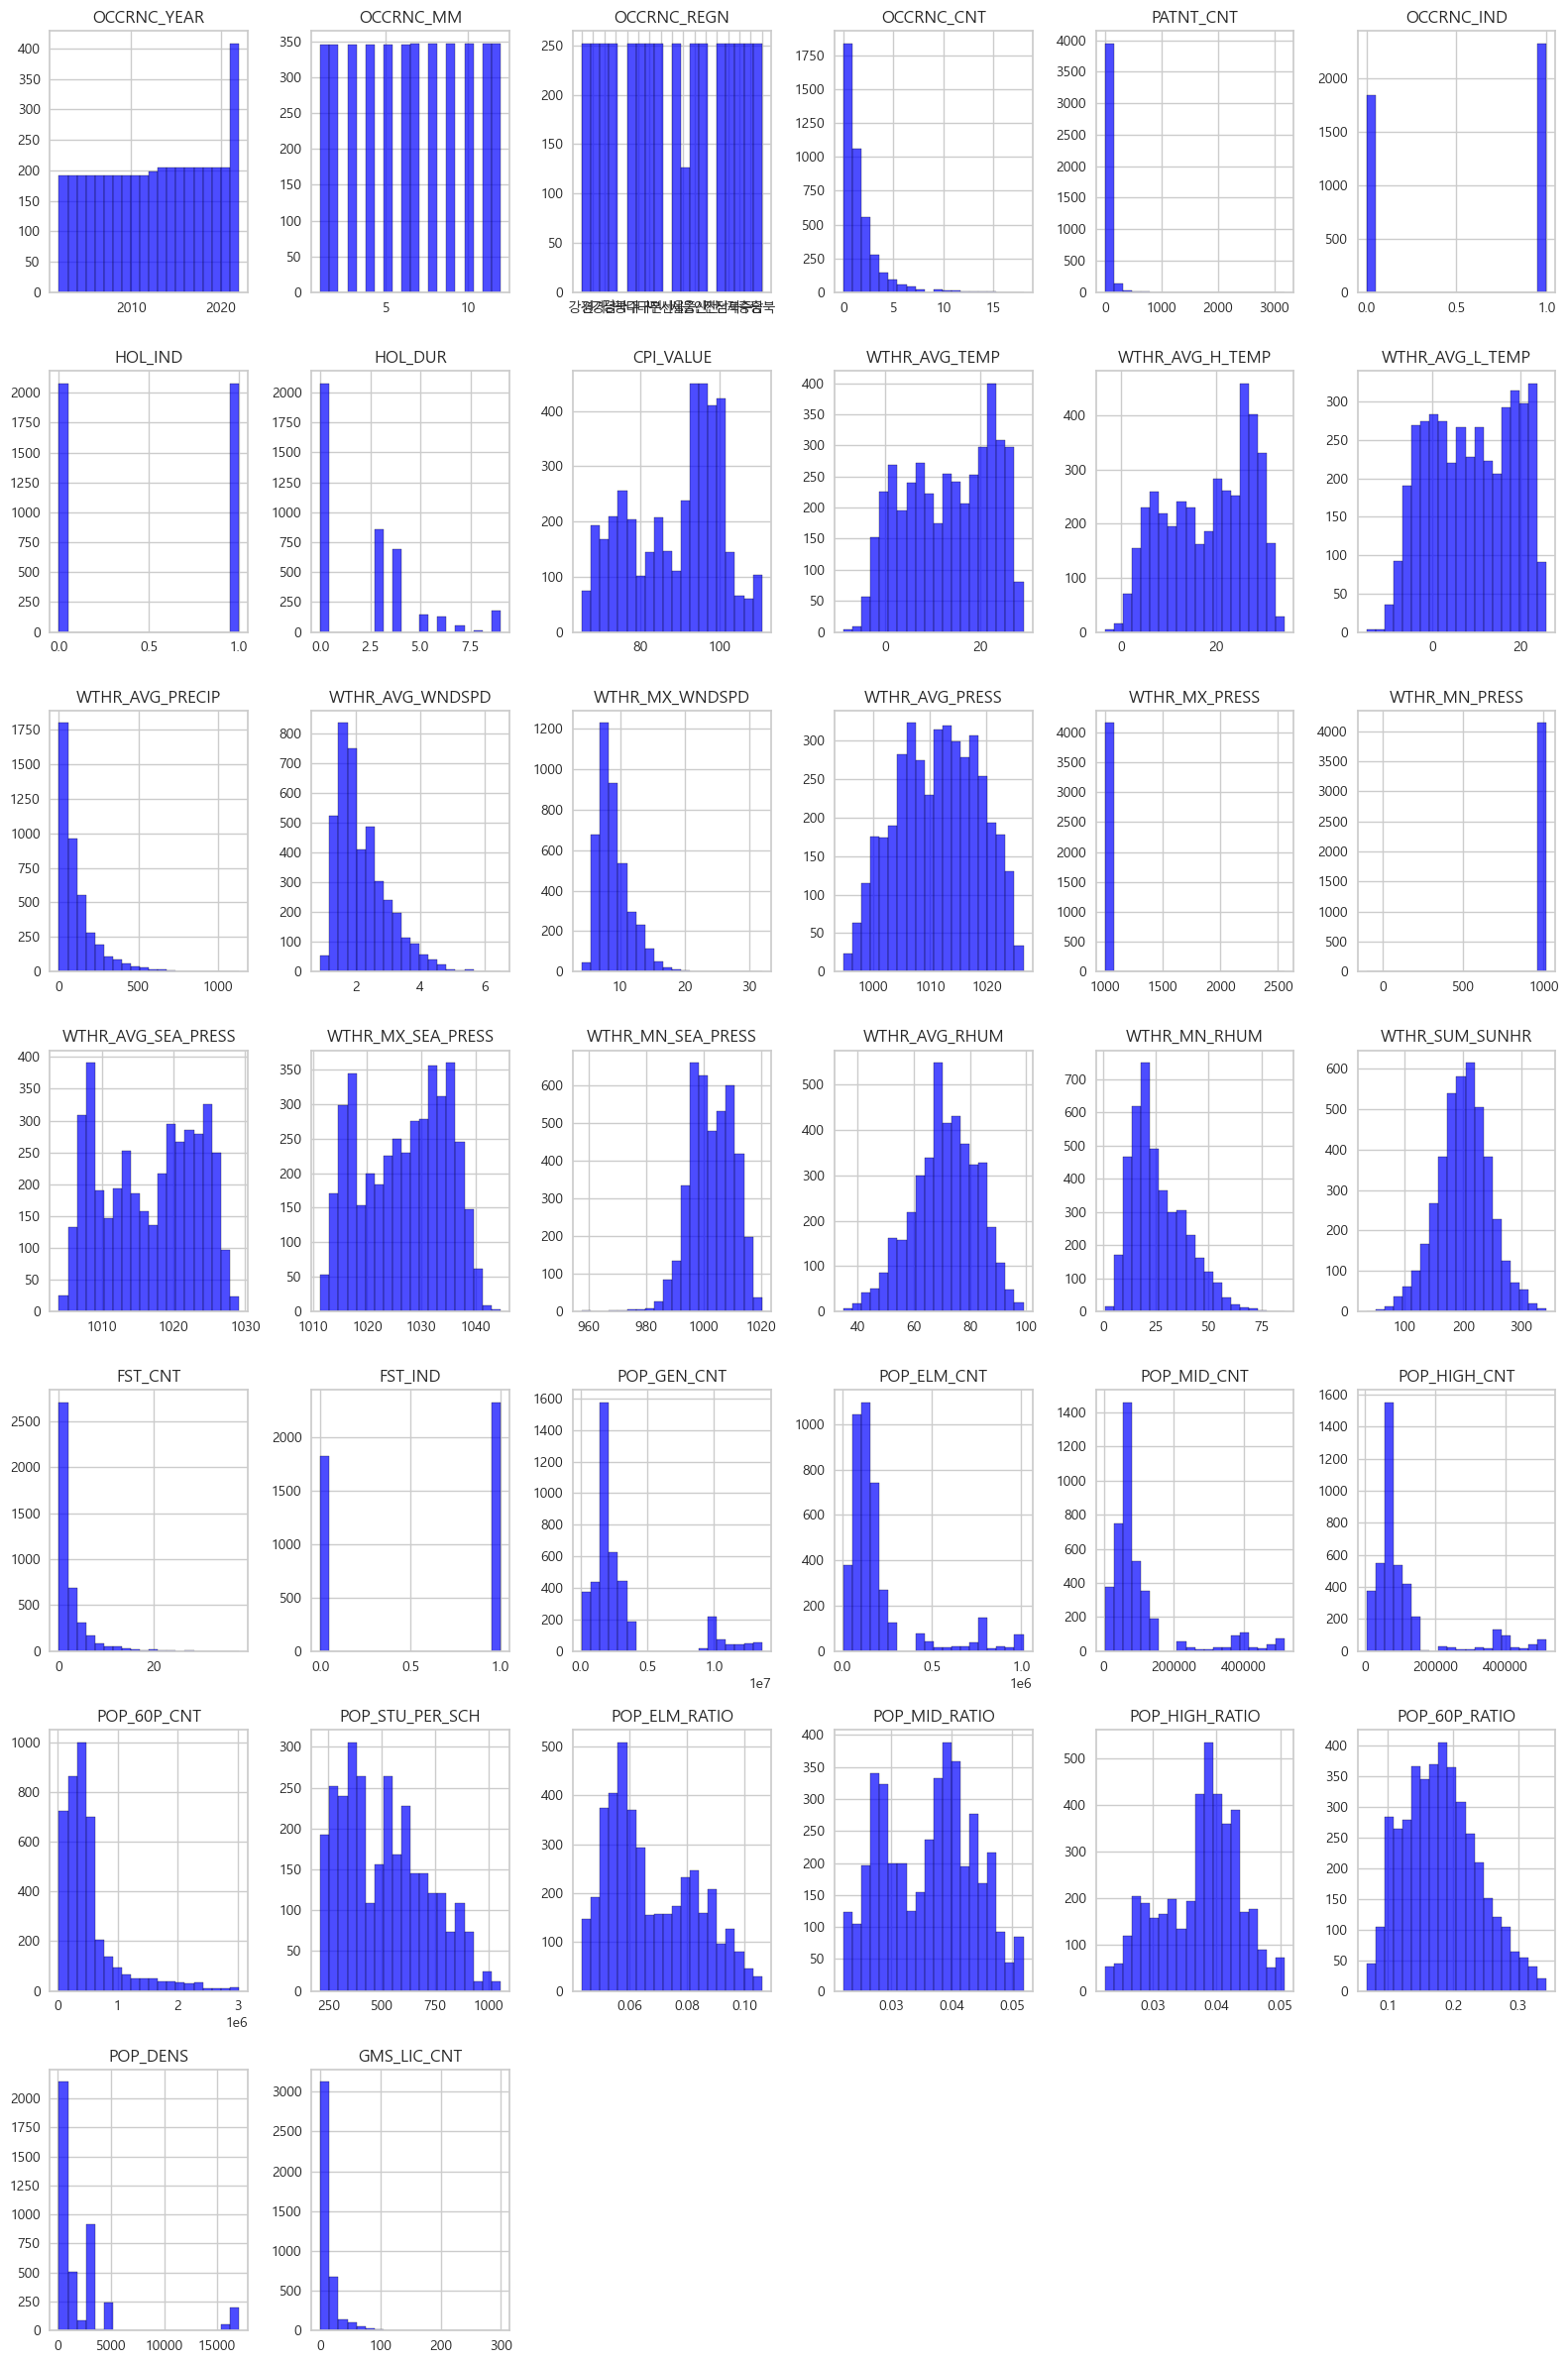

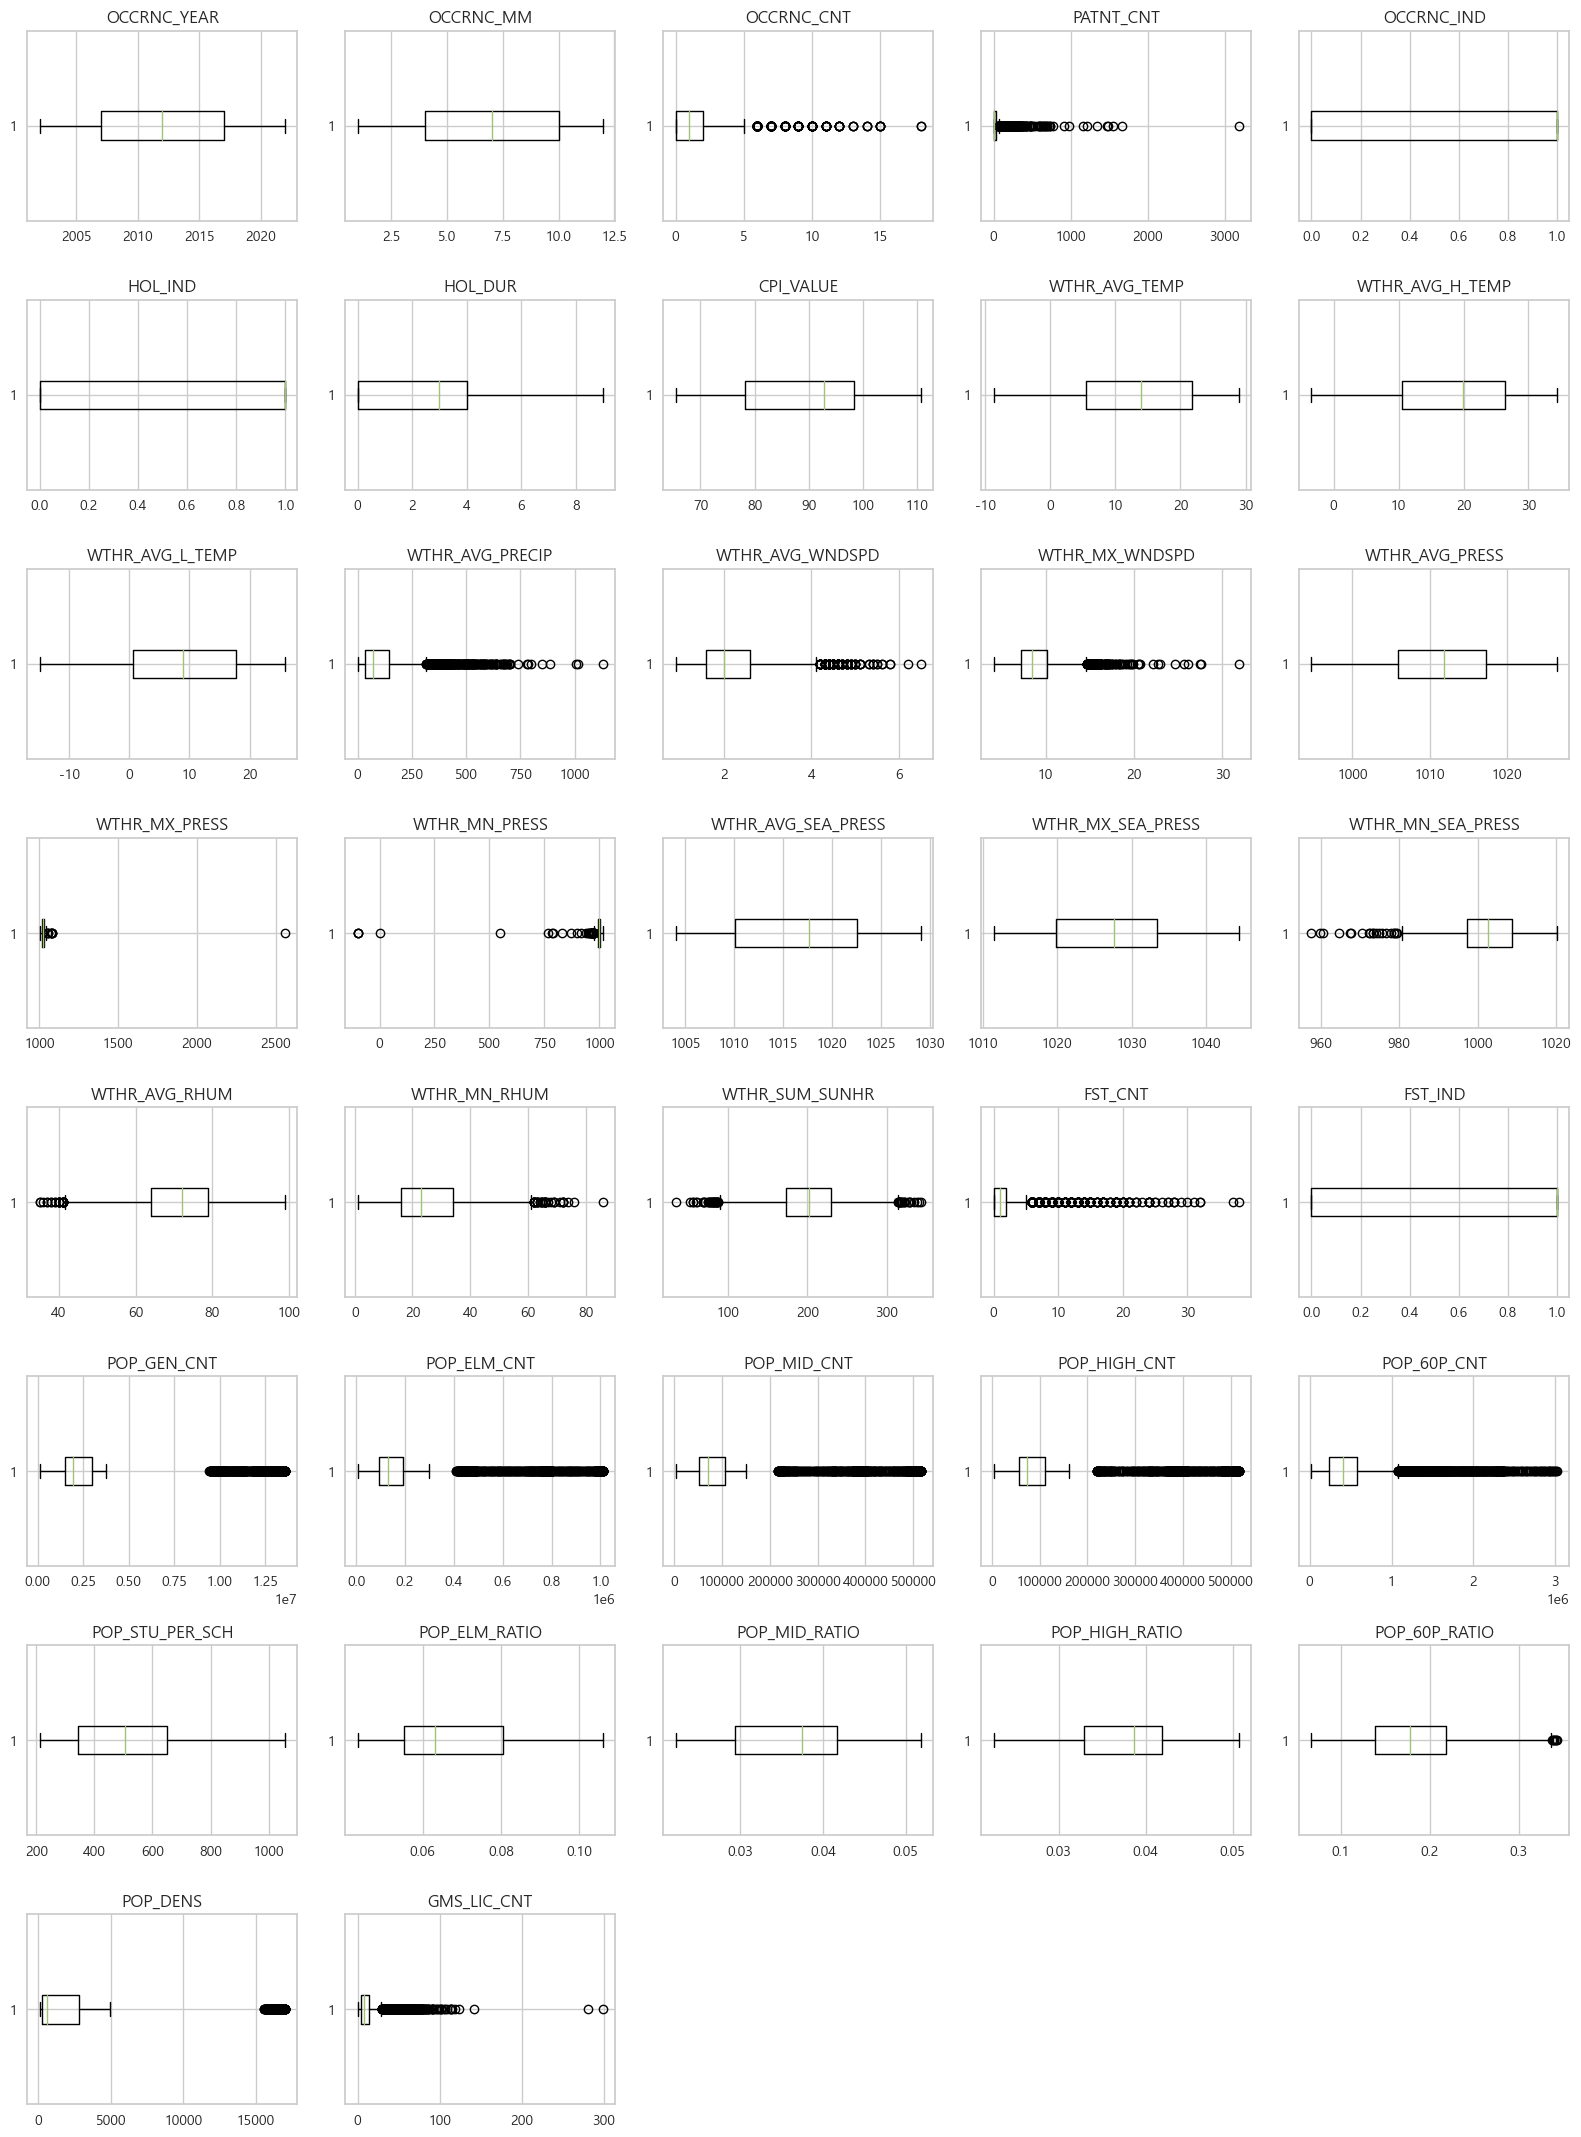

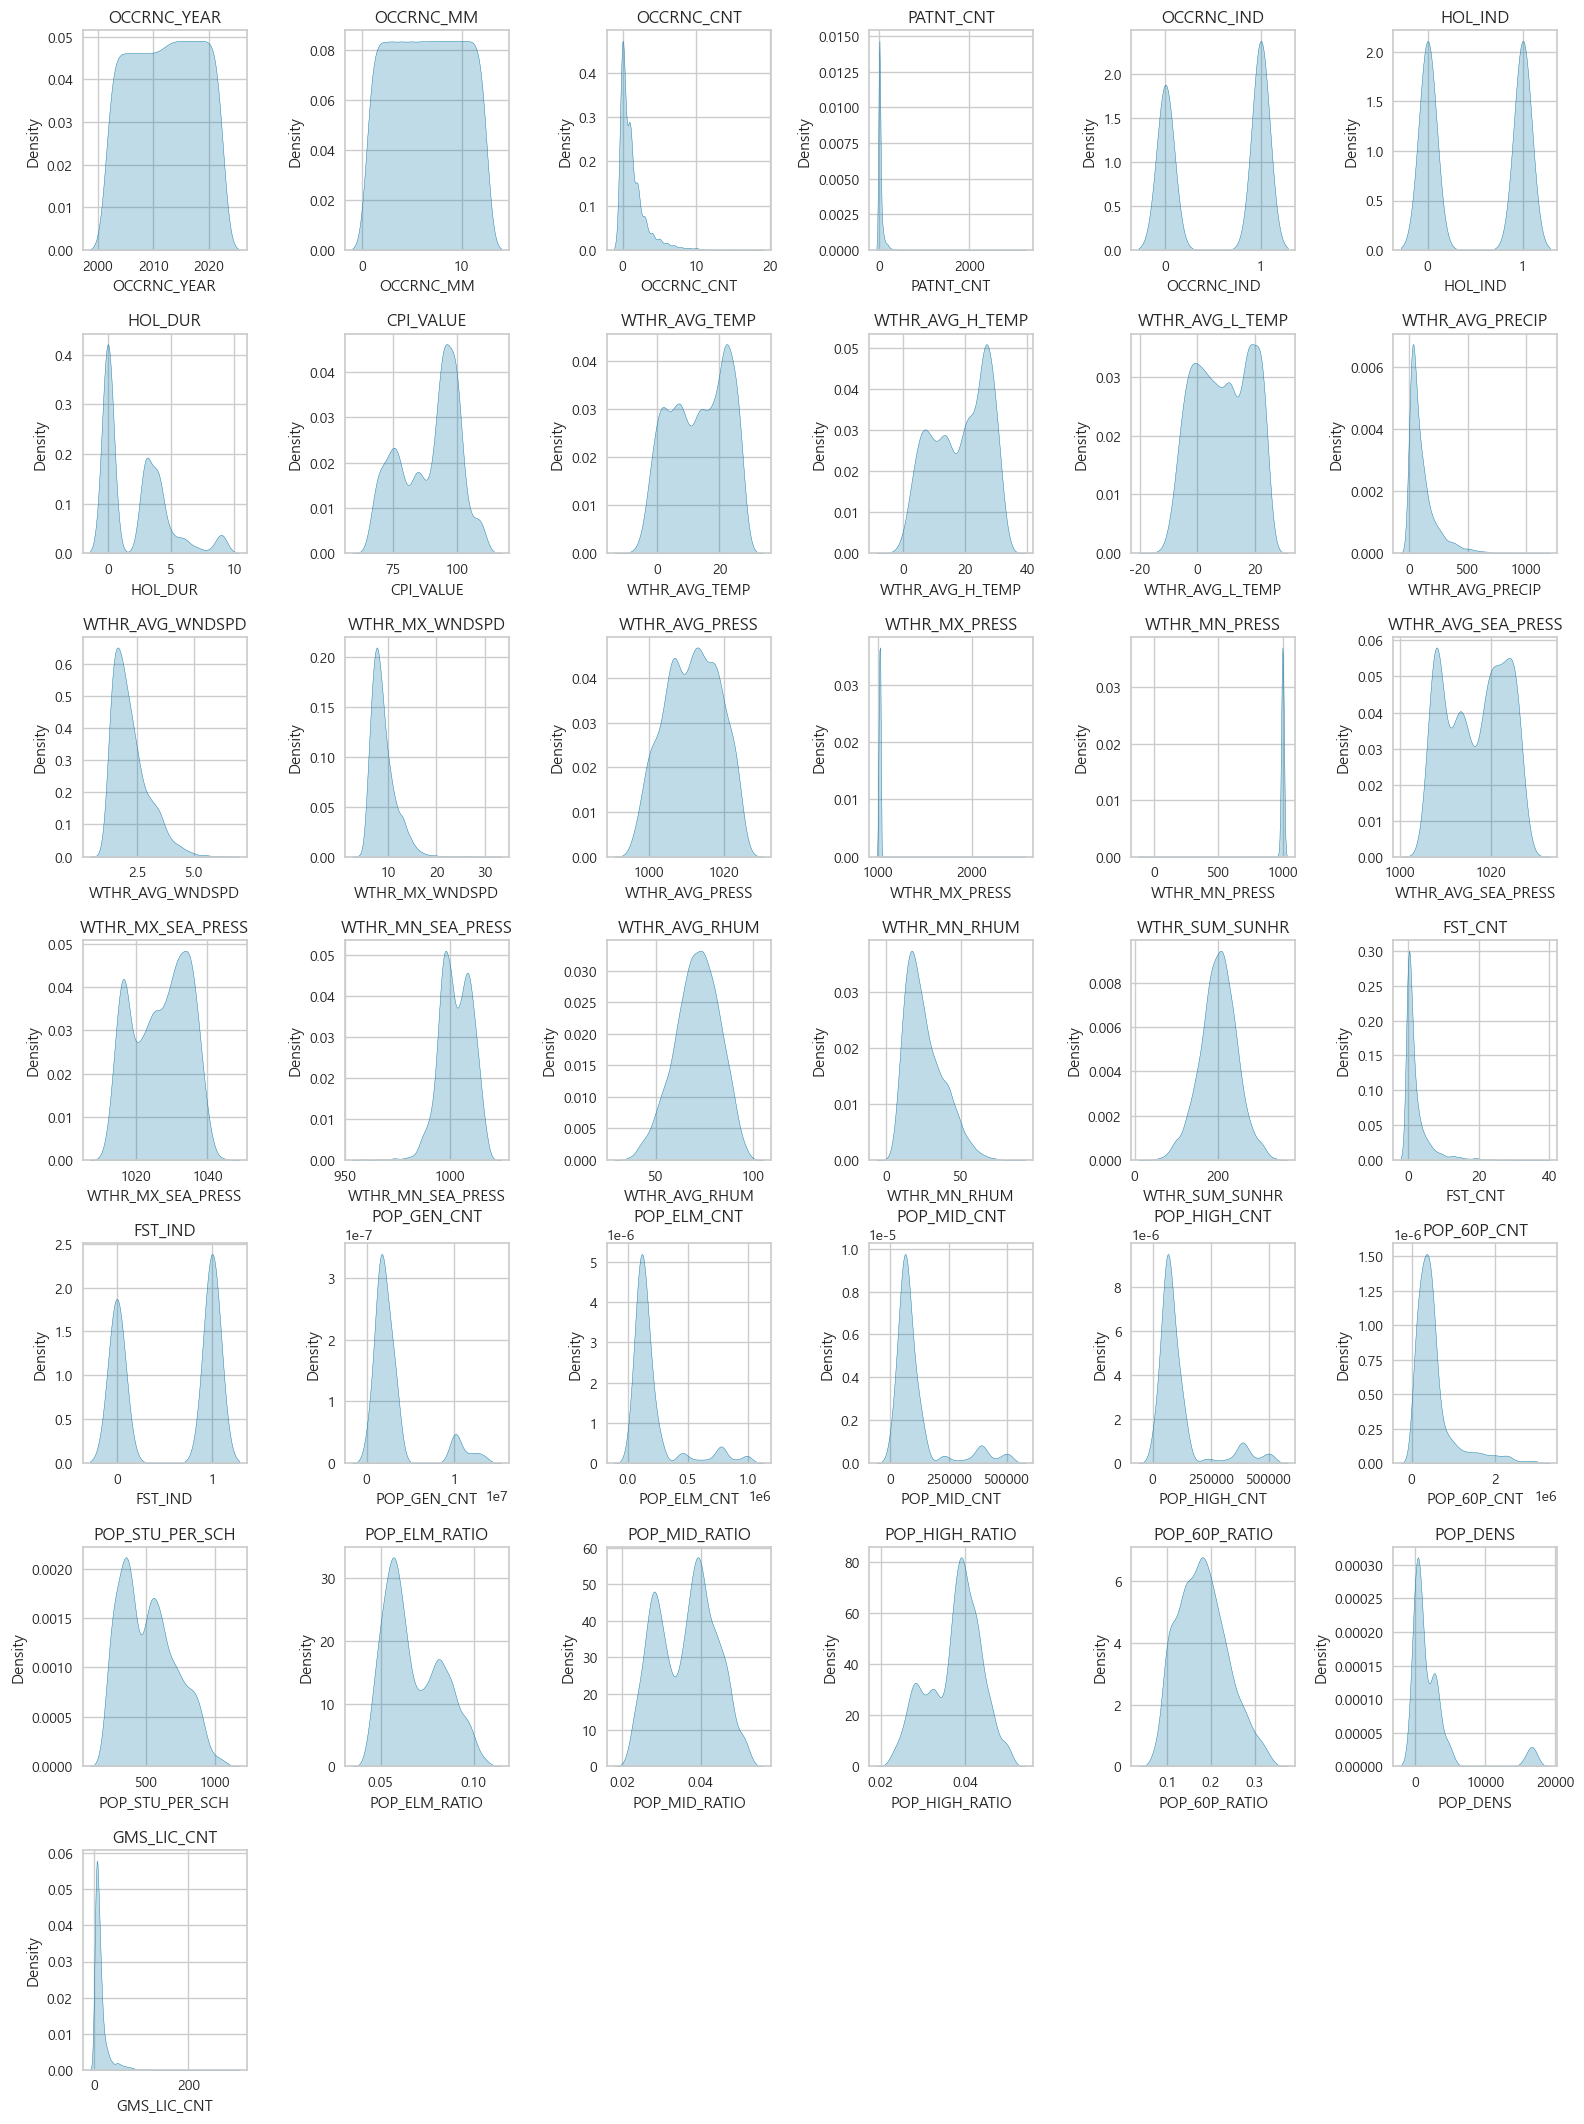

In [54]:
import matplotlib.pyplot as plt

# 변수별 분포 확인을 위한 히스토그램
plt.figure(figsize=(16, 24))
for i, col in enumerate(df1.columns, 1):
    plt.subplot(7, 6, i)
    plt.hist(df1[col].dropna(), bins=20, color='blue', edgecolor='black', alpha=0.7)
    plt.title(col)
plt.tight_layout()
plt.show()

# 박스플롯을 통한 이상치 시각화
plt.figure(figsize=(16, 24))
numeric_columns = df1.select_dtypes(include=[np.number]).columns  # 수치형 컬럼 선택
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(9, 5, i)
    plt.boxplot(df1[col].dropna(), vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

# 타겟 변수를 포함한 전체 변수의 밀도그래프
plt.figure(figsize=(16, 24))
for idx, col in enumerate(numeric_columns):
    if col in df1.columns:  # 컬럼이 존재하는지 확인
        plt.subplot(8, 6, idx + 1)
        ax = sns.kdeplot(df1[col], shade=True)
        plt.title(f'{col}')
plt.tight_layout()
plt.show()

### 2. 원인물질별 데이터 분포 및 이상치 시각화

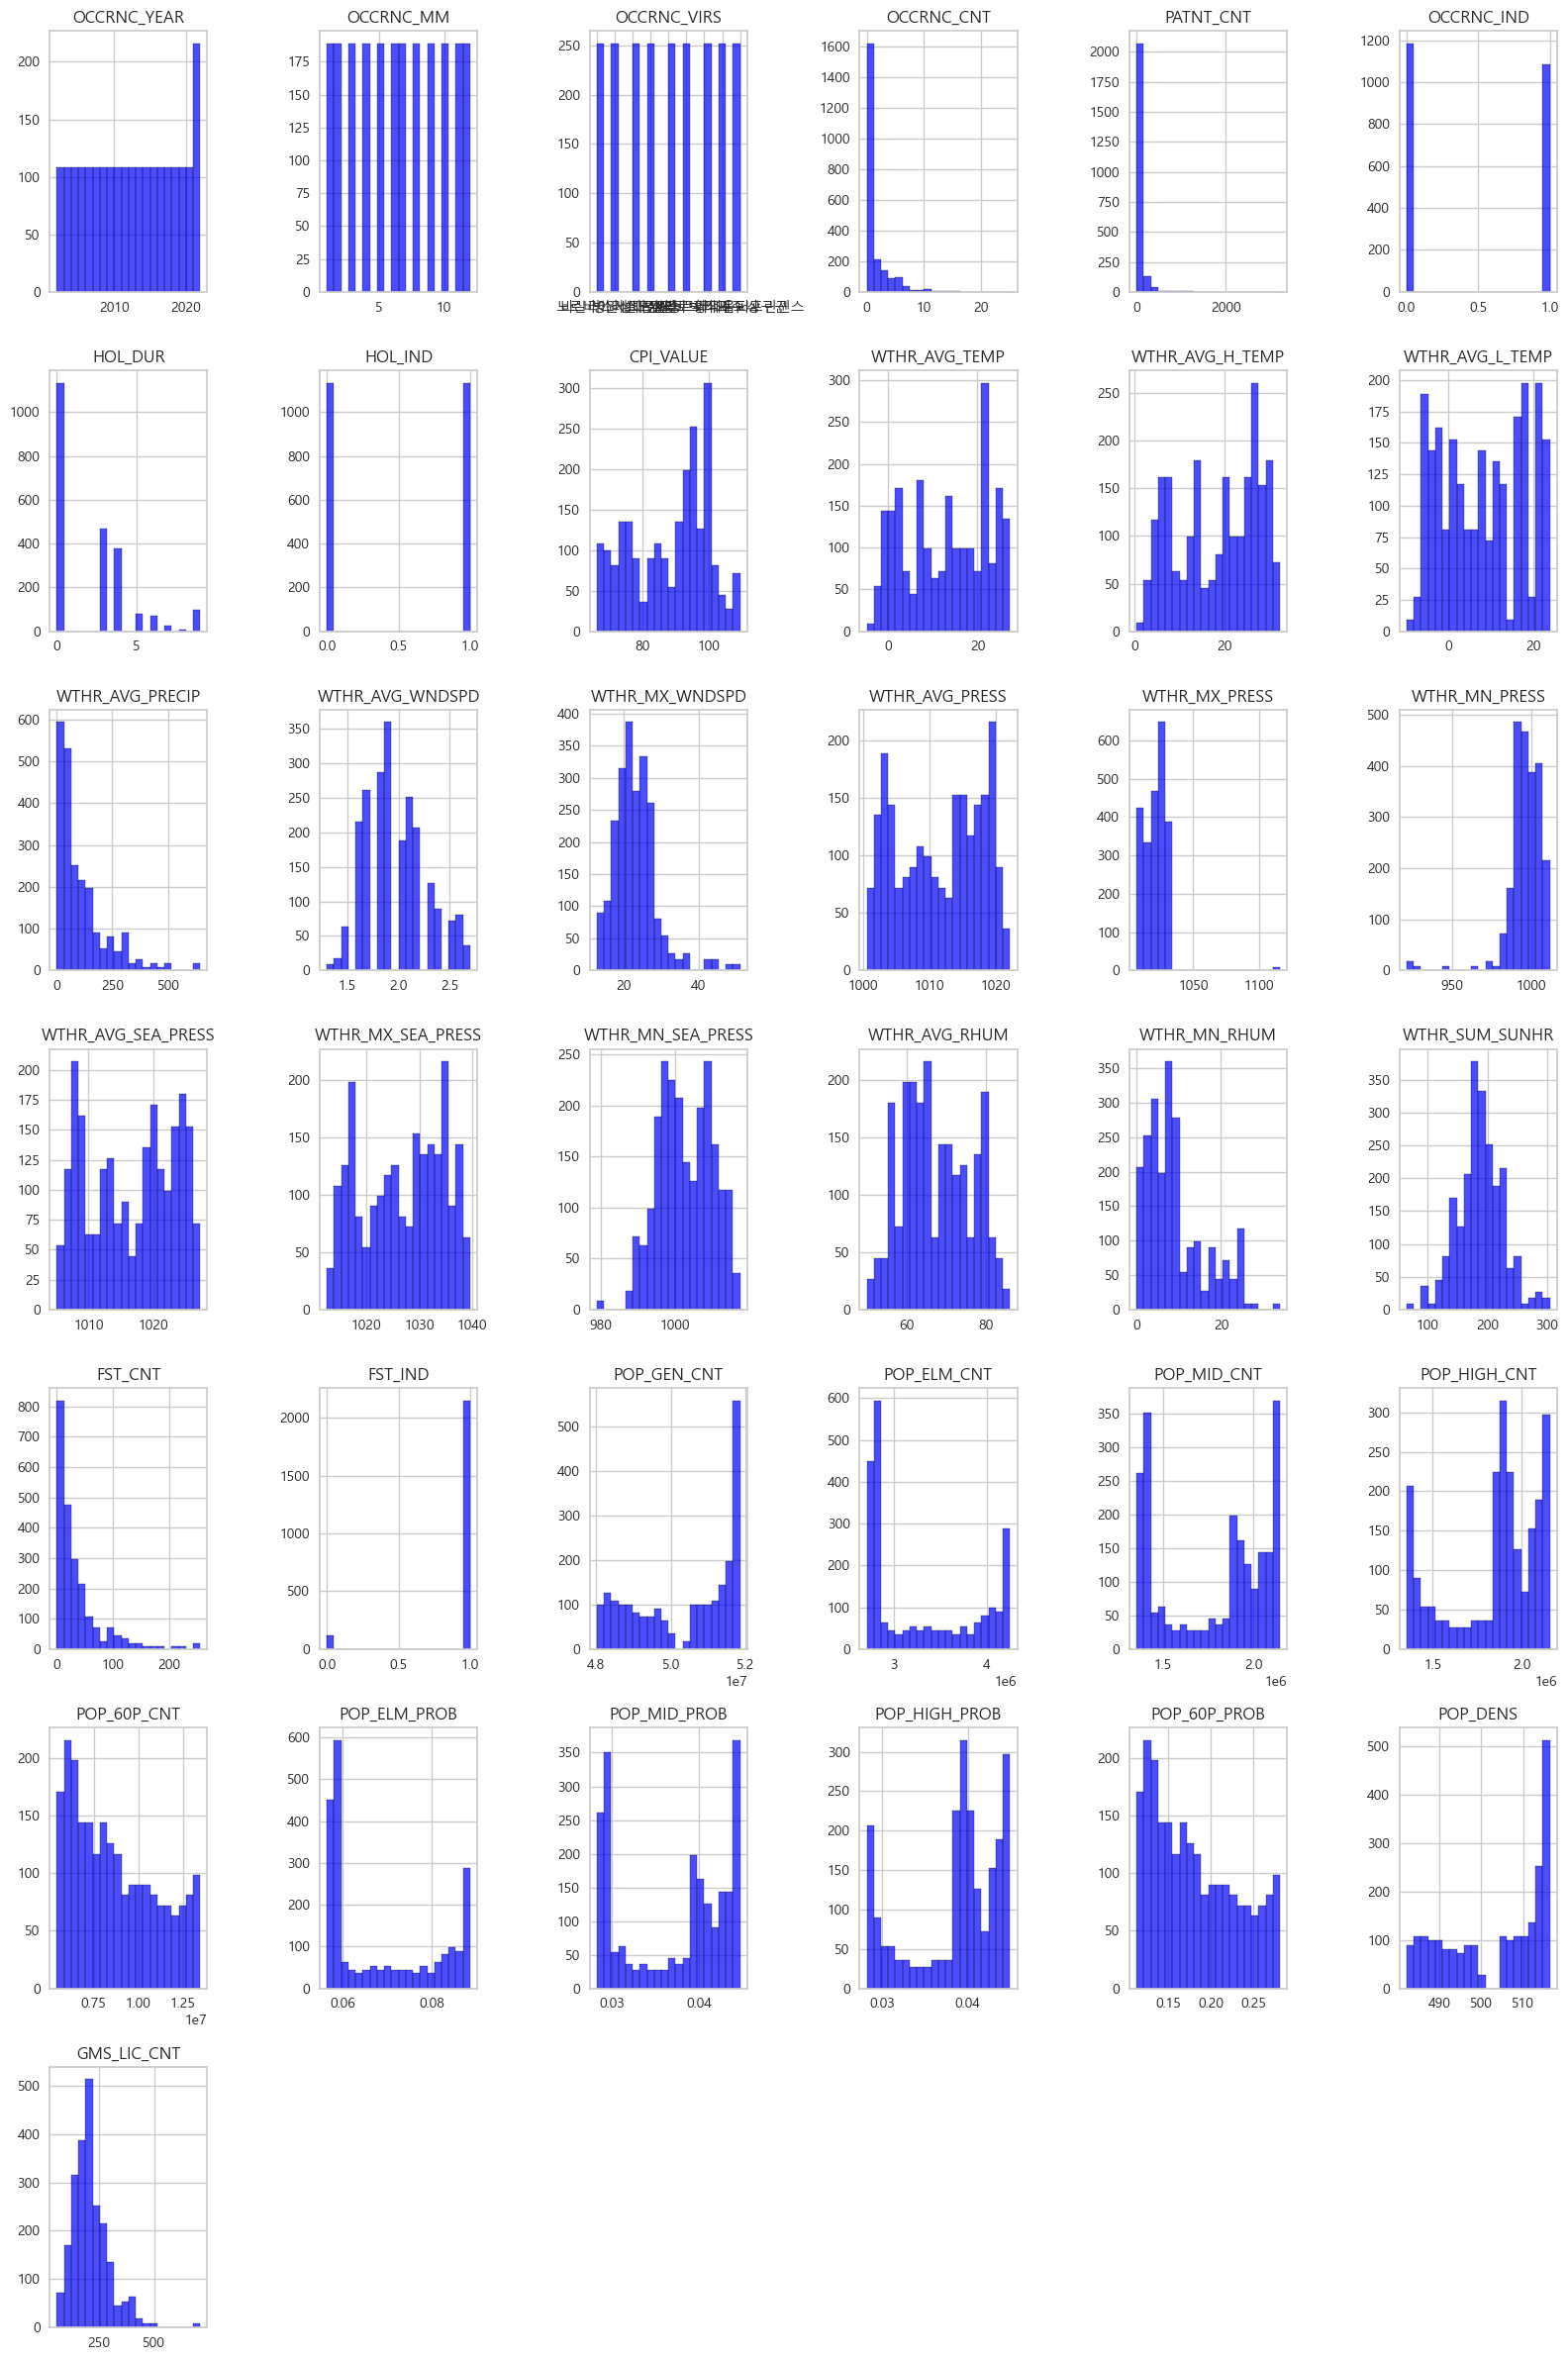

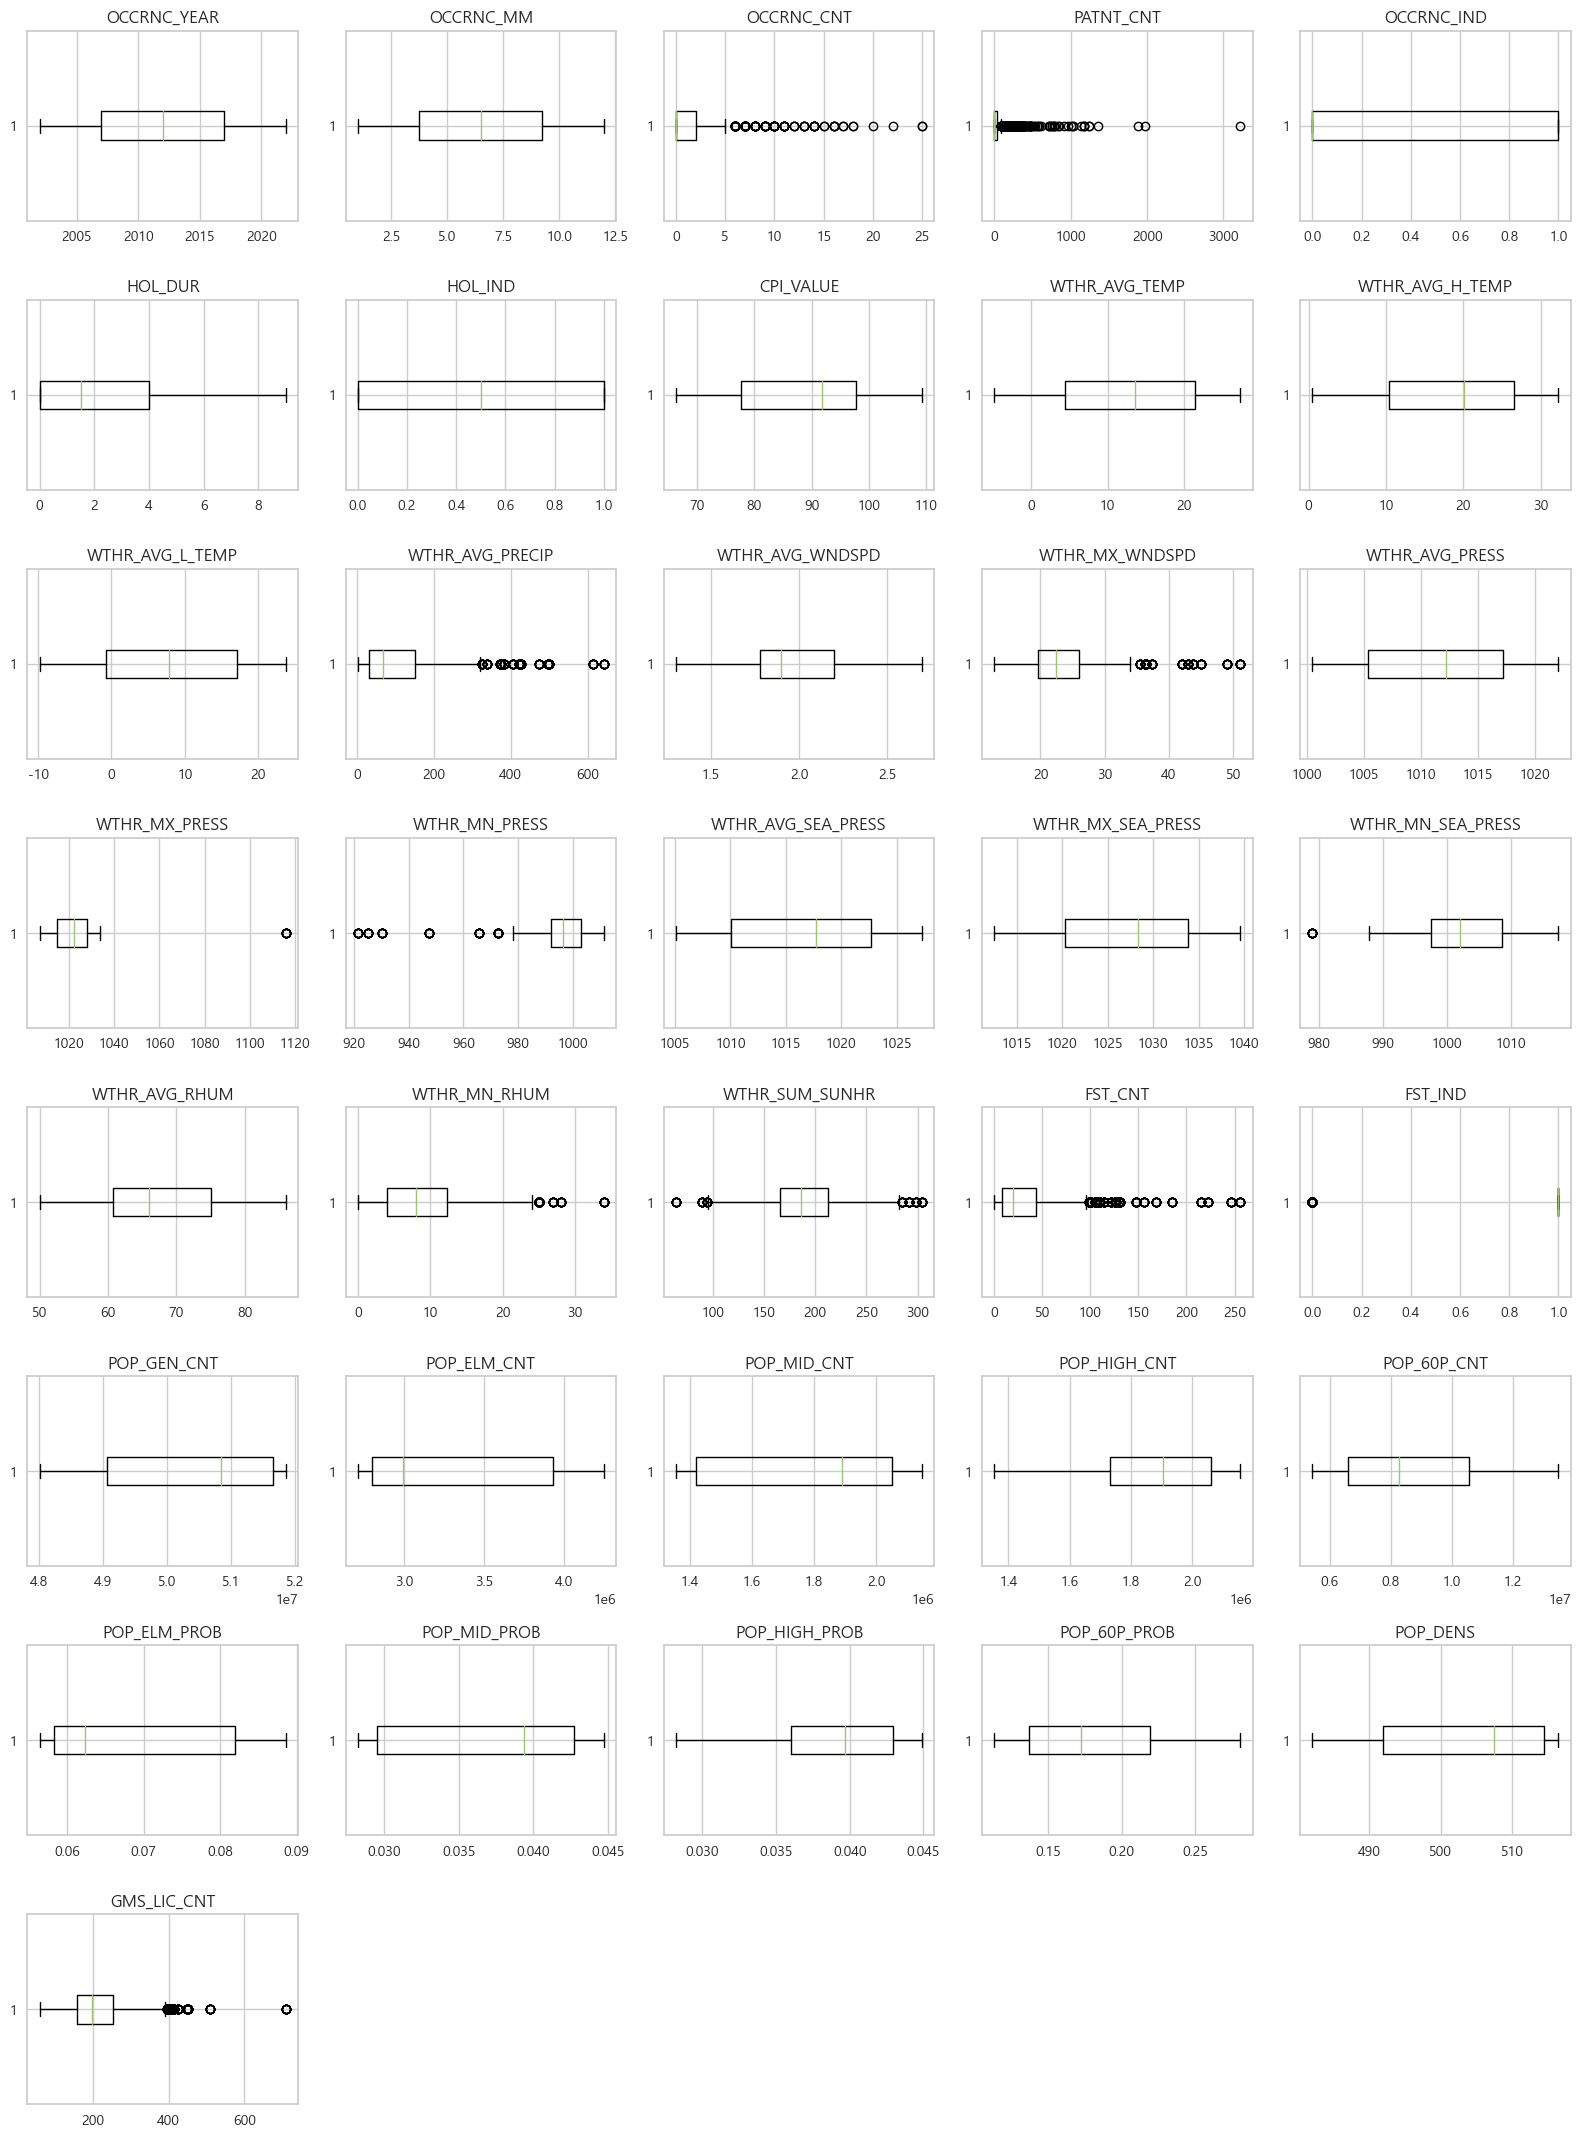

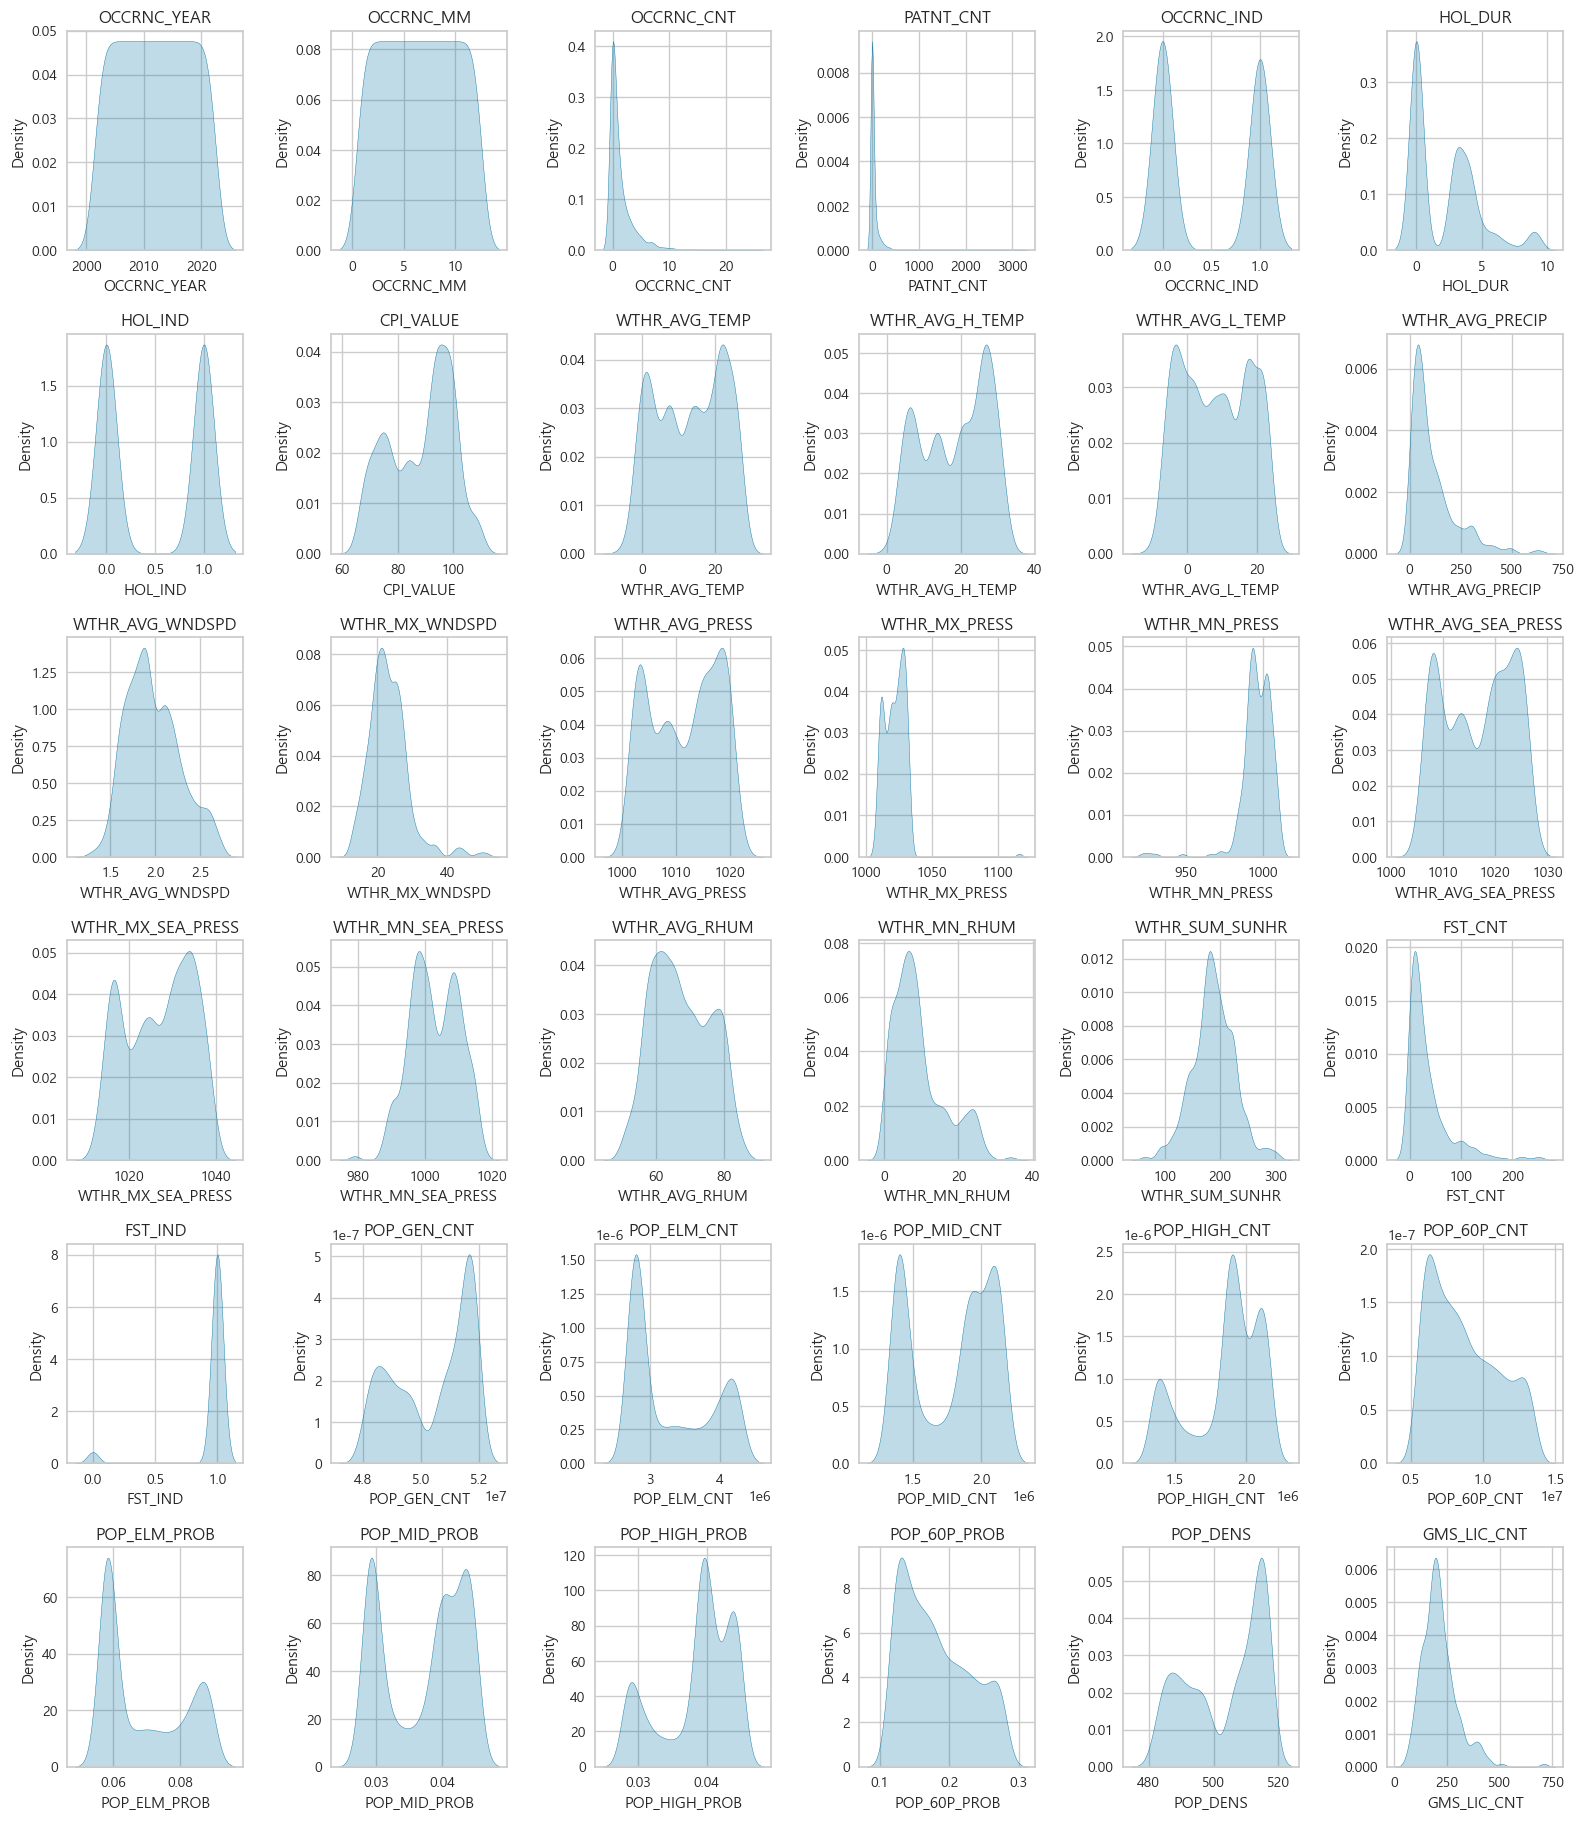

In [55]:
import matplotlib.pyplot as plt

# 변수별 분포 확인을 위한 히스토그램
plt.figure(figsize=(16, 24))
for i, col in enumerate(df2.columns, 1):
    plt.subplot(7, 6, i)
    plt.hist(df2[col].dropna(), bins=20, color='blue', edgecolor='black', alpha=0.7)
    plt.title(col)
plt.tight_layout()
plt.show()

# 박스플롯을 통한 이상치 시각화
plt.figure(figsize=(16, 24))
numeric_columns = df2.select_dtypes(include=[np.number]).columns  # 수치형 컬럼 선택
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(9, 5, i)
    plt.boxplot(df2[col].dropna(), vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

# 타겟 변수를 포함한 전체 변수의 밀도그래프
plt.figure(figsize=(16, 24))
for idx, col in enumerate(numeric_columns):
    if col in df2.columns:  # 컬럼이 존재하는지 확인
        plt.subplot(8, 6, idx + 1)
        ax = sns.kdeplot(df2[col], shade=True)
        plt.title(f'{col}')
plt.tight_layout()
plt.show()

# **Ⅳ. Master Table EDA**

## **1. 전체 통계**

In [56]:
region_df = pd.read_csv('Foodborne_Region_MasterTable.csv')
cause_df = pd.read_csv('Foodborne_Cause_MasterTable4.csv')

### 1. 연도별 발생건수 및 환자수_바 차트

In [57]:
def plot_dual_axis(data, x_column, y1_column, y2_column, x_label, y1_label, y2_label, title, bar_color, line_color, bg_color):

    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # 그래프 배경 색 지정
    fig.patch.set_facecolor(bg_color)
    ax1.set_facecolor(bg_color)

    # 데이터 그룹화
    grouped_data = data.groupby(x_column).sum()

    # 첫 번째 축 - 발생 건수 (막대 그래프)
    bars = ax1.bar(grouped_data.index, grouped_data[y1_column], color=bar_color, label='Occurrence Count')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y1_label, color=bar_color)
    ax1.tick_params(axis='y', labelcolor=bar_color)
    ax1.set_ylim(0, 1500)     # y축 범위 설정
    ax1.set_yticks(range(0,1501, 100))       # y축 눈금 가격 설정

    # 막대 그래프에 값 라벨 추가
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3.5),
                    textcoords="offset points",
                    ha='center', va='bottom')

    # 두 번째 축 - 환자 수 (선 그래프)
    ax2 = ax1.twinx()
    lines = ax2.plot(grouped_data.index, grouped_data[y2_column], color=line_color, marker='o', label='Patient Count')
    ax2.set_ylabel(y2_label, color=line_color)
    ax2.tick_params(axis='y', labelcolor=line_color)
    ax2.set_ylim(0, 12000)     # y축 범위 설정
    ax2.set_yticks(range(0,12001, 1000))       # y축 눈금 가격 설정

    # 선 그래프에 값 라벨 추가
    for i, txt in enumerate(grouped_data[y2_column]):
        ax2.annotate(f'{int(txt)}', (grouped_data.index[i], txt),
                    textcoords="offset points", xytext=(-5, 0),  # 왼쪽에 간격을 둠
                    ha='right', color=line_color)  # 왼쪽 정렬

    plt.title(title)
    fig.tight_layout()
    plt.show()

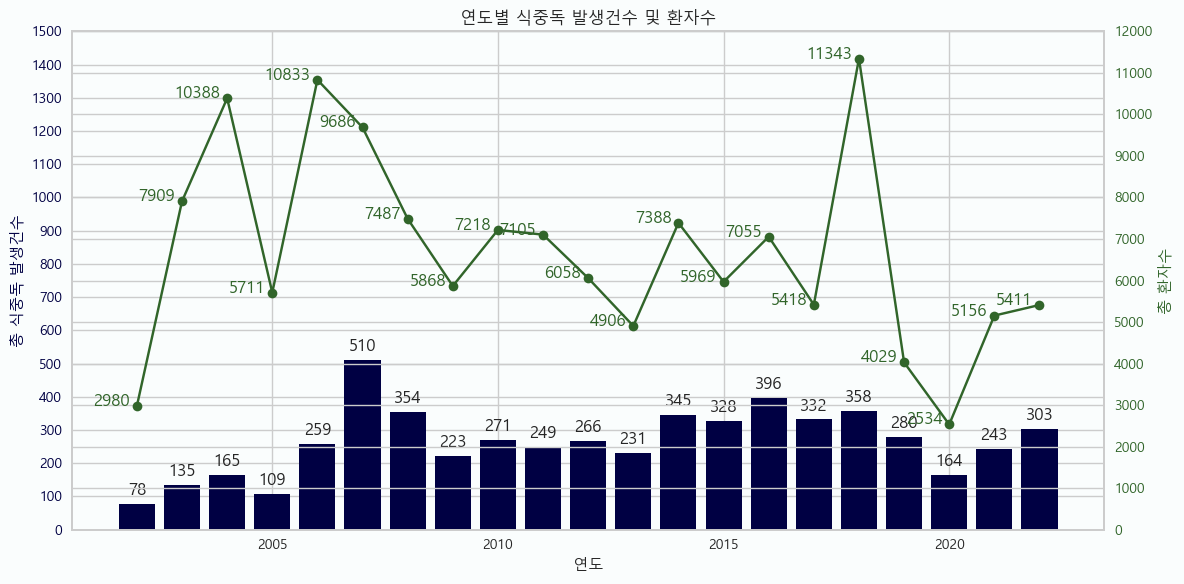

In [58]:
# 연도별 발생 건수와 환자 수 시각화
plot_dual_axis(
    data=region_df,
    x_column='OCCRNC_YEAR',
    y1_column='OCCRNC_CNT',
    y2_column='PATNT_CNT',
    x_label='연도',
    y1_label='총 식중독 발생건수',
    y2_label='총 환자수',
    title='연도별 식중독 발생건수 및 환자수',
    bar_color='#000043',
    line_color='#31652a',
    bg_color = '#FAFDFD'        # 그래프 배경 색상
    )


In [59]:
old_value = 4029  # 2019 환자 수
new_value = 2543  # 2020 환자 수

# 2019년 대비 2020년 증감
percentage_decrease = ((old_value - new_value) / old_value) * 100
print(f"2019년 대비 2020년 환자 수 증감: {percentage_decrease:.2f}%")
print('='*30)

patient_counts_5_years = [5418,11343,4029, 2534, 5156, 5411]  # 최근 5년 환자 수 (2017,2019,2020,2021,2022)
average_5_years = sum(patient_counts_5_years) / len(patient_counts_5_years)
percentage_difference_avg = ((average_5_years - new_value) / average_5_years) * 100
print(f"최근 5년간 평균 환자 수: {average_5_years:.2f}명")
print(f"2020년 환자 수와 5년 평균의 차이: {percentage_difference_avg:.2f}%")

2019년 대비 2020년 환자 수 증감: 36.88%
최근 5년간 평균 환자 수: 5648.50명
2020년 환자 수와 5년 평균의 차이: 54.98%


### 2. 연도별 식중독 발생건수 대비 환자수

In [60]:
# 연도별 원인물질별 발생 건수와 환자 수 집계
yearly_pathogen_summary = cause_df.groupby(['OCCRNC_YEAR', 'OCCRNC_VIRS']).agg({'OCCRNC_CNT': 'sum', 'PATNT_CNT': 'sum'})

# 발생 건수 대비 환자 수 비율 계산
yearly_pathogen_summary['발생건수_대비_환자수'] = yearly_pathogen_summary['PATNT_CNT'] / yearly_pathogen_summary['OCCRNC_CNT']
yearly_pathogen_summary

OCCRNC_CNT  PATNT_CNT  발생건수_대비_환자수
OCCRNC_YEAR OCCRNC_VIRS                                     
2002        노로바이러스                 0          0          NaN
            바실러스세레우스               0          0          NaN
            병원성대장균                 2         63    31.500000
            살모넬라                  25        589    23.560000
            원충                     0          0          NaN
...                              ...        ...          ...
2022        원충                     6         24     4.000000
            장염비브리오                 0          0          NaN
            캠필로박터제주니              14        270    19.285714
            클로스트리디움퍼프린젠스          10        993    99.300000
            황색포도상구균               10        157    15.700000

[189 rows x 3 columns]

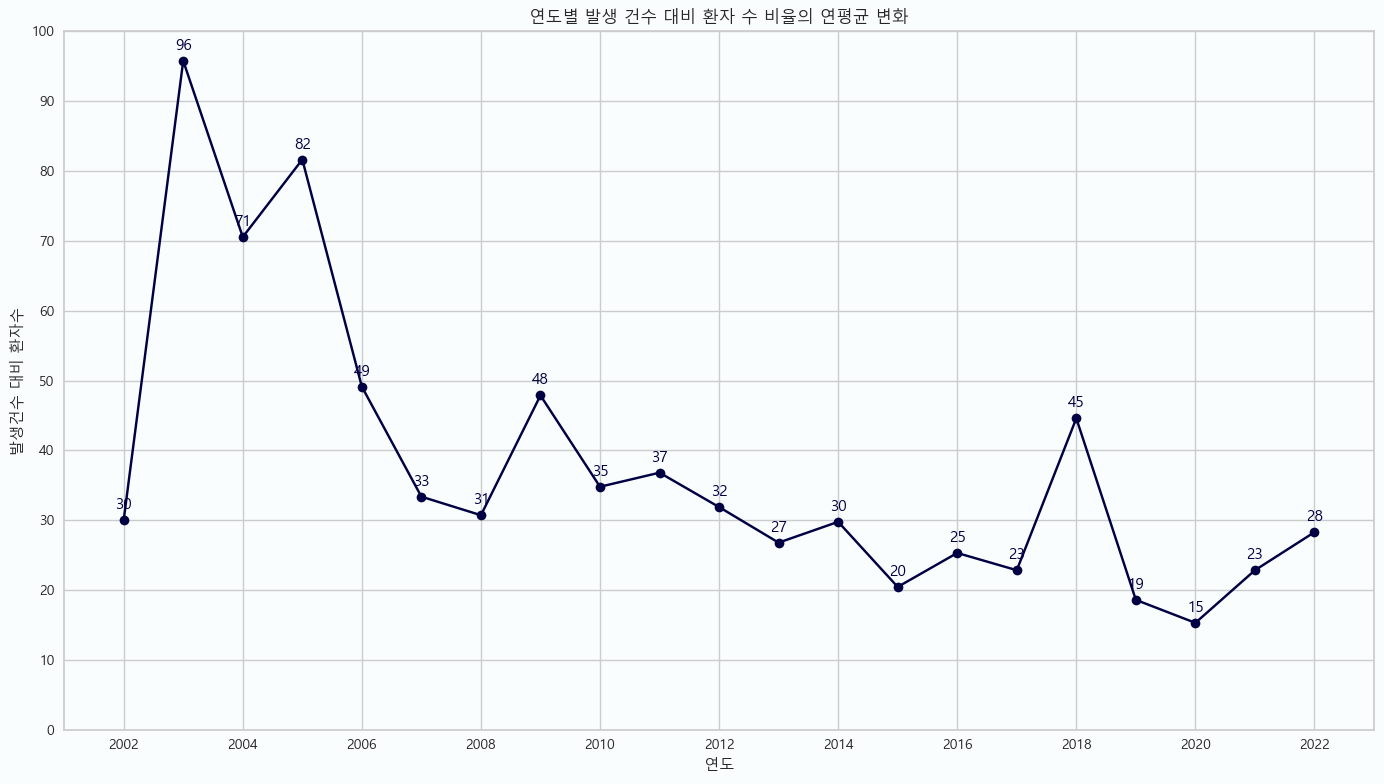

In [61]:

# 연도별 발생 건수 대비 환자 수 비율의 연평균 계산
average_yearly_pathogen_summary = yearly_pathogen_summary.groupby('OCCRNC_YEAR')['발생건수_대비_환자수'].mean()

# 연평균 원인물질별 발생 건수 대비 환자 수 비율 시각화
plt.figure(figsize=(14, 8))

# 그래프 외부 배경색 설정
plt.gcf().patch.set_facecolor('#FAFDFD')
# 그래프 내부 배경색 설정
ax = plt.gca()
ax.set_facecolor('#FAFDFD')

plt.plot(average_yearly_pathogen_summary.index, average_yearly_pathogen_summary, marker='o', color='#000043', linestyle='-')

# y축 범위와 tick 설정
plt.ylim(0, 100)  # y축 범위 설정
plt.yticks(range(0, 101, 10))  # y축 tick 단위 설정

plt.xlim(2001, 2023)  # x축 범위 설정
plt.xticks(range(2002, 2023, 2))  # x축 tick 단위 설정

# 각 포인트에 수치값 표시
for x, y in zip(average_yearly_pathogen_summary.index, average_yearly_pathogen_summary):
    plt.text(x, y + 1, f'{y:.0f}', ha='center', va='bottom', fontsize=11, color='#000043')  # 값 표시 (y + 1로 위쪽에 위치)



plt.title('연도별 발생 건수 대비 환자 수 비율의 연평균 변화')
plt.xlabel('연도')
plt.ylabel('발생건수 대비 환자수')
#plt.legend(title='비율')
plt.grid(True)
plt.tight_layout()
plt.show()


### 3. 원인물질별 식중독 발생건수 대비 환자수

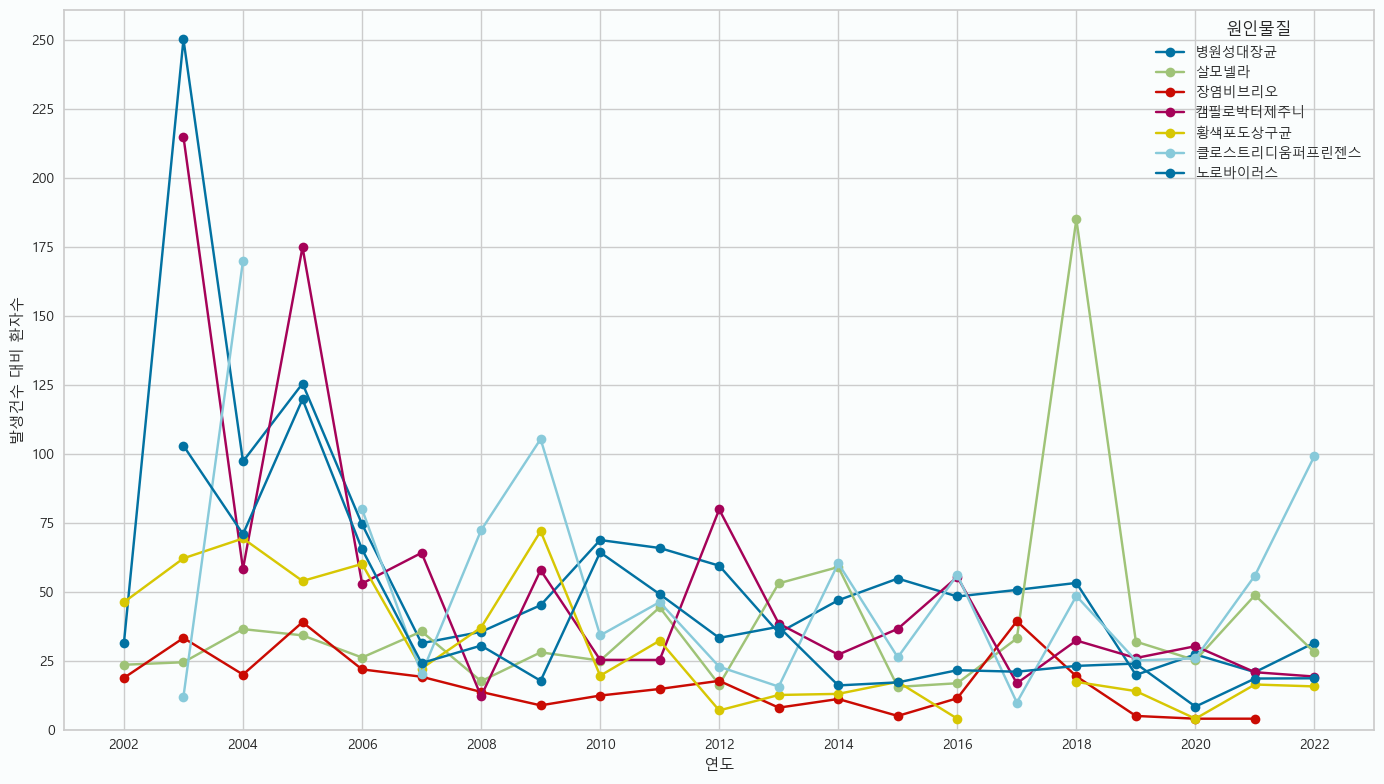

In [62]:
pathogen_list = ['병원성대장균', '살모넬라', '장염비브리오', '캠필로박터제주니', '황색포도상구균', '클로스트리디움퍼프린젠스', '노로바이러스']

# 연도별 원인물질별 발생 건수와 환자 수 집계
yearly_pathogen_summary = cause_df.groupby(['OCCRNC_YEAR', 'OCCRNC_VIRS']).agg({'OCCRNC_CNT': 'sum', 'PATNT_CNT': 'sum'})

# 발생 건수 대비 환자 수 비율 계산
yearly_pathogen_summary['발생건수/환자수 비율'] = yearly_pathogen_summary['PATNT_CNT'] / yearly_pathogen_summary['OCCRNC_CNT']

# 연도별 원인물질별 발생 건수 대비 환자 수 비율 변화 시각화
plt.figure(figsize=(14, 8))

# 그래프 외부 배경색 설정
plt.gcf().patch.set_facecolor('#FAFDFD')
# 그래프 내부 배경색 설정
ax = plt.gca()
ax.set_facecolor('#FAFDFD')

for pathogen in pathogen_list:
    plt.plot(yearly_pathogen_summary.loc[(slice(None), pathogen), :].index.get_level_values('OCCRNC_YEAR'),
            yearly_pathogen_summary.loc[(slice(None), pathogen), '발생건수/환자수 비율'],
            marker='o', label=pathogen)

plt.ylim(0, 261)  # y축 범위 설정
plt.yticks(range(0, 261, 25))  # y축 tick 단위 설정

plt.xlim(2001, 2023)  # x축 범위 설정
plt.xticks(range(2002, 2023, 2))  # x축 tick 단위 설정

#plt.title('연도별 원인물질별 발생 건수 대비 환자 수 비율 변화')
plt.xlabel('연도')
plt.ylabel('발생건수 대비 환자수')
plt.legend(title='원인물질')
plt.grid(True)
plt.tight_layout()
plt.show()


## **2. 원인 물질별 식중독 발생 분석**

### 1. 원인물질별 발생건수 파이차트

In [63]:
def cause_analysis_pie(cause_df, cause_col, occurrence_col):
    cause_summary = cause_df.groupby(cause_col)[[occurrence_col]].sum().sort_values(by=occurrence_col, ascending=False)

    # 데이터 및 비율 계산
    total_occurrences = cause_summary[occurrence_col].sum()
    cause_summary['percent'] = cause_summary[occurrence_col] / total_occurrences * 100

    labels = cause_summary.index
    sizes = cause_summary[occurrence_col]

    pastel_colors = ['#393C78','#63793C','#8B6D35','#833B3A','#7A4172','#5355A1','#8CA256','#BC9D40','#AC484C','#A45193','#6C6FCD','#B5CF6F','#E6B959','#D4606C','#CD6DBC','#9C9EDC','#CEDB9E','#E6CB96','#E6969D','#DD9ED5']
    # "tab20b" 팔레트에서 상위 5개 색상 선택
    #tab20b_colors = plt.cm.get_cmap('tab20b', 14)  # 5개의 색상 추출
    #pastel_colors = [f'#{int(r*255):02X}{int(g*255):02X}{int(b*255):02X}' for r, g, b, _ in tab20b_colors.colors]

    # Plotly 파이 차트 생성
    fig = go.Figure(
        data=[go.Pie(  
            labels=labels,
            values=sizes,
            hole=0,  
            textinfo='percent+label',  
            insidetextorientation='horizontal', 
            marker=dict(colors=pastel_colors[:len(labels)], line=dict(color='#FAFDFD', width=3)),
            sort = False,
            rotation=90,
            direction='clockwise',
            #direction='counterclockwise',
            showlegend=False
        )]
    )

    # 차트 레이아웃 설정
    fig.update_layout(
        # title={
        #     'text': "원인 물질별 식중독 발생 건수 비율",
        #     'x': 0.5,  
        #     'xanchor': 'center',
        #     'yanchor': 'top'
        # },
        font=dict(size=14, family='Arial', color='black'),
        annotations=[], 
        width=800,  
        height=800,
        paper_bgcolor='#FAFDFD',
        legend=dict(
            font=dict(size=14, family='Arial', weight='bold')
        )
    )
    
    fig.show()

In [64]:
cause_analysis_pie(cause_df, 'OCCRNC_VIRS', 'OCCRNC_CNT')

### 2. 식중독 유발 순위 및 누적 비율

In [65]:
# 원인별 환자 수 및 발생 건수를 요약
cause_summary = cause_df.groupby('OCCRNC_VIRS')[['OCCRNC_CNT']].sum().sort_values(by='OCCRNC_CNT', ascending=False)

# 데이터 및 비율 계산
total_occurrences = cause_summary['OCCRNC_CNT'].sum()
cause_summary['percent'] = cause_summary['OCCRNC_CNT'] / total_occurrences * 100
cause_summary['cumulative_percent'] = cause_summary['percent'].cumsum()

cause_summary


,OCCRNC_CNT,percent,cumulative_percent
OCCRNC_VIRS,,,
노로바이러스,880,26.960784,26.960784
병원성대장균,678,20.772059,47.732843
살모넬라,475,14.552696,62.285539
장염비브리오,265,8.118873,70.404412
황색포도상구균,234,7.169118,77.573529
캠필로박터제주니,214,6.556373,84.129902
원충,196,6.004902,90.134804
클로스트리디움퍼프린젠스,191,5.851716,95.986520
바실러스세레우스,131,4.013480,100.000000


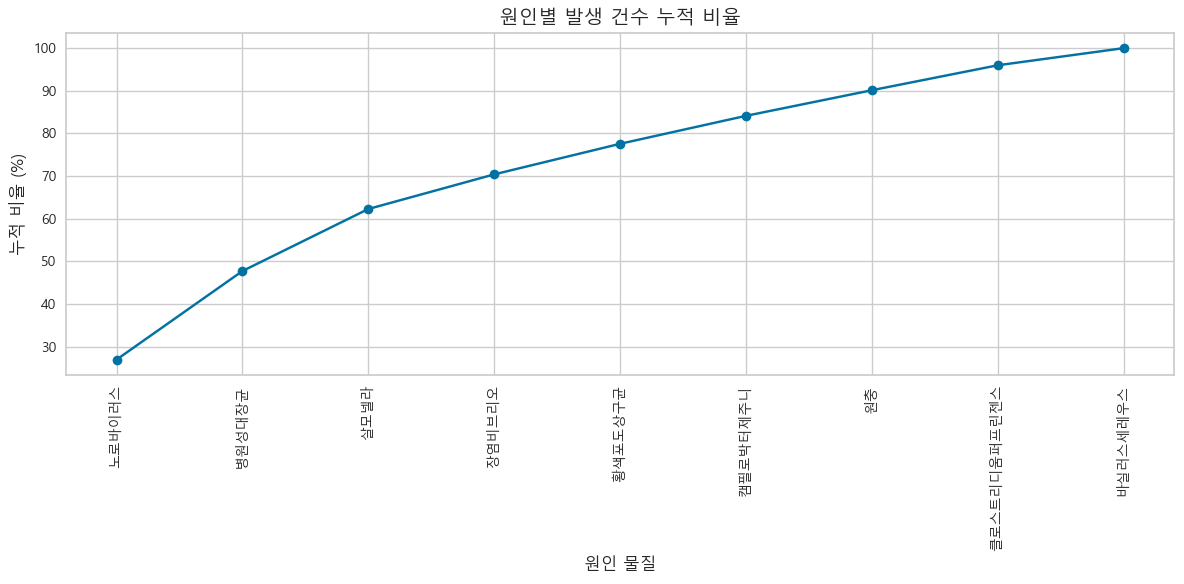

In [66]:
# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(cause_summary.index, cause_summary['cumulative_percent'], marker='o', linestyle='-', color='b')

# 그래프 레이블 및 제목 설정
plt.title('원인별 발생 건수 누적 비율', fontsize=14)
plt.xlabel('원인 물질', fontsize=12)
plt.ylabel('누적 비율 (%)', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(True)

# 그래프 보여주기
plt.tight_layout()
plt.show()

### 3. Sorted 원인물질별 발생건수 파이차트 (원인불명, 1% 미만 제외)

In [67]:
def cause_analysis_pie(cause_df, cause_col, occurrence_col):
    cause_summary = cause_df.groupby(cause_col)[[occurrence_col]].sum().sort_values(by=occurrence_col, ascending=False)

    # 데이터 및 비율 계산
    total_occurrences = cause_summary[occurrence_col].sum()
    cause_summary['percent'] = cause_summary[occurrence_col] / total_occurrences * 100

    labels = cause_summary.index
    sizes = cause_summary[occurrence_col]

    #pastel_colors = ['#393C78','#63793C','#8B6D35','#833B3A','#7A4172','#5355A1','#8CA256','#BC9D40','#AC484C','#A45193','#6C6FCD','#B5CF6F','#E6B959','#D4606C','#CD6DBC','#9C9EDC','#CEDB9E','#E6CB96','#E6969D','#DD9ED5']
    pastel_colors = ['#63793C','#8B6D35','#833B3A','#7A4172','#5355A1','#8CA256','#BC9D40','#AC484C','#A45193']
    # "tab20b" 팔레트에서 상위 5개 색상 선택
    #tab20b_colors = plt.cm.get_cmap('tab20b', 14)  # 5개의 색상 추출
    #pastel_colors = [f'#{int(r*255):02X}{int(g*255):02X}{int(b*255):02X}' for r, g, b, _ in tab20b_colors.colors]

    # Plotly 파이 차트 생성
    fig = go.Figure(
        data=[go.Pie(  
            labels=labels,
            values=sizes,
            hole=0,  
            textinfo='percent+label',  
            insidetextorientation='horizontal', 
            marker=dict(colors=pastel_colors[:len(labels)], line=dict(color='#FAFDFD', width=3)),
            sort = False,
            rotation=90,
            direction='clockwise',
            #direction='counterclockwise',
            showlegend=False
        )]
    )

    # 차트 레이아웃 설정
    fig.update_layout(
        # title={
        #     'text': "원인 물질별 식중독 발생 건수 비율",
        #     'x': 0.5,  
        #     'xanchor': 'center',
        #     'yanchor': 'top'
        # },
        font=dict(size=14, family='Arial'),
        annotations=[], 
        width=800,  
        height=800,
        paper_bgcolor='#FAFDFD',
        legend=dict(
            font=dict(size=14, family='Arial', weight='bold')
        )
    )
    
    fig.show()

In [68]:
cause_analysis_pie(cause_df, 'OCCRNC_VIRS', 'OCCRNC_CNT')

### 4. 원인 물질별 발생 건수 대비 환자 수 비율

#### 1) 원인물질 전체

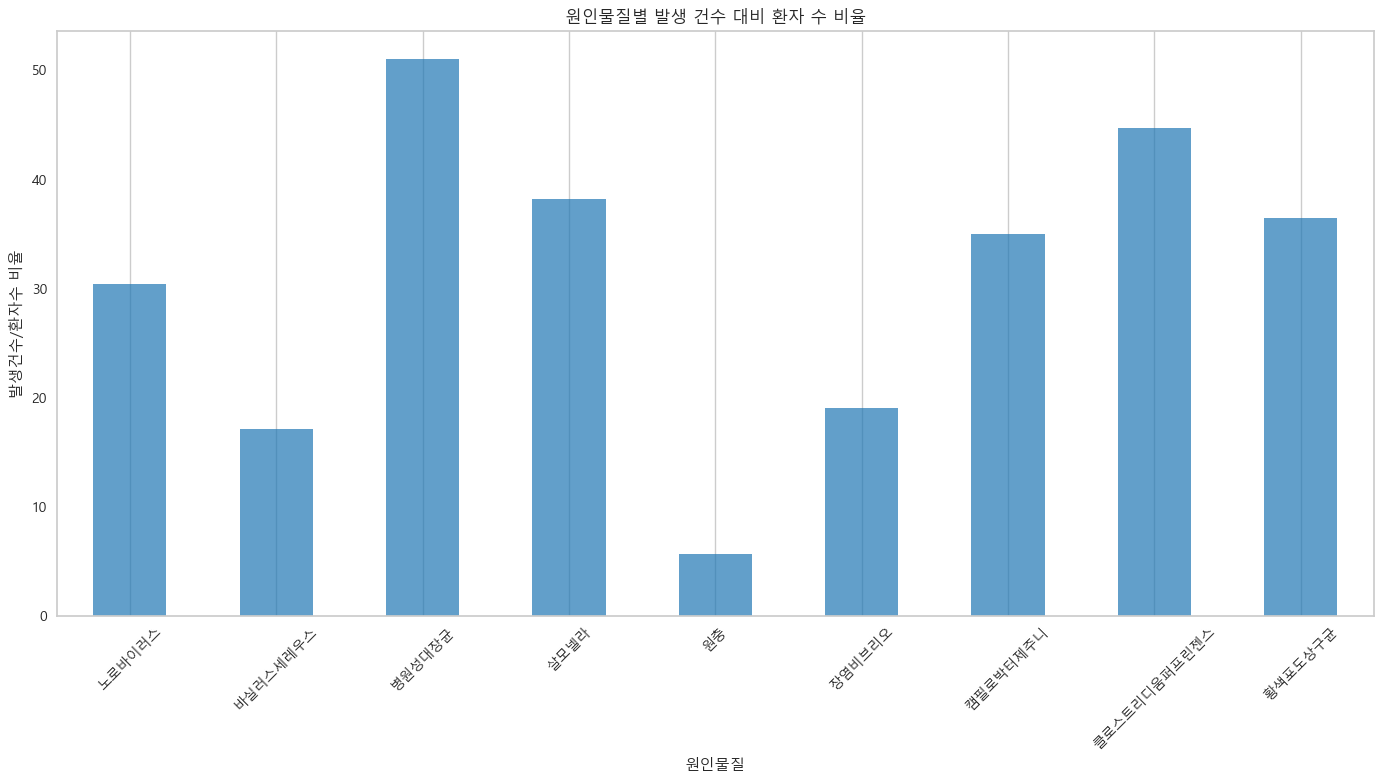

In [69]:
# 원인물질별별 발생 건수와 환자 수 집계
pathogen_summary = cause_df.groupby('OCCRNC_VIRS').agg({'OCCRNC_CNT': 'sum', 'PATNT_CNT': 'sum'})

# 발생 건수 대비 환자 수 비율 계산
pathogen_summary['발생건수/환자수 비율'] = pathogen_summary['PATNT_CNT'] / pathogen_summary['OCCRNC_CNT']

# 비율 시각화
plt.figure(figsize=(14, 8))
pathogen_summary['발생건수/환자수 비율'].plot(kind='bar', color='#1f77b4', alpha=0.7)
plt.title('원인물질별 발생 건수 대비 환자 수 비율')
plt.xlabel('원인물질')
plt.ylabel('발생건수/환자수 비율')
plt.xticks(rotation=45, ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### 2) Sorted 원인물질

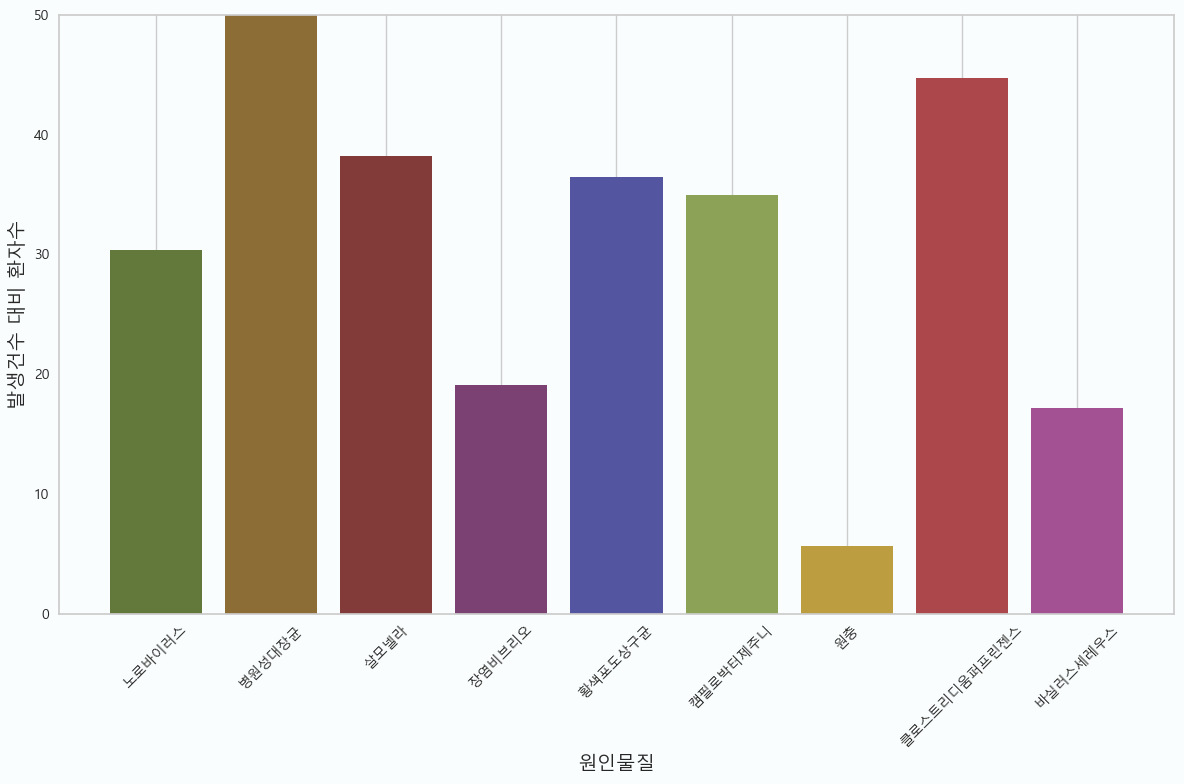

In [70]:
selected_pathogens = [
    '노로바이러스','병원성대장균','살모넬라','장염비브리오',
    '황색포도상구균','캠필로박터제주니','원충','클로스트리디움퍼프린젠스','바실러스세레우스'
    ]

# 원인물질별별 발생 건수와 환자 수 집계
pathogen_summary = cause_df.groupby('OCCRNC_VIRS').agg({'OCCRNC_CNT': 'sum', 'PATNT_CNT': 'sum'})

# 발생 건수 대비 환자 수 비율 계산
pathogen_summary['발생건수/환자수 비율'] = pathogen_summary['PATNT_CNT'] / pathogen_summary['OCCRNC_CNT']
filtered_pathogen_summary = pathogen_summary.loc[selected_pathogens]

colors = {
    '노로바이러스': '#63793C',
    '병원성대장균': '#8B6D35',
    '살모넬라': '#833B3A',
    '장염비브리오': '#7A4172',
    '황색포도상구균': '#5355A1',
    '캠필로박터제주니': '#8CA256',
    '원충': '#BC9D40',
    '클로스트리디움퍼프린젠스': '#AC484C',
    '바실러스세레우스': '#A45193'
}

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFDFD')

plt.bar(
    filtered_pathogen_summary.index,  # x축: 원인물질
    filtered_pathogen_summary['발생건수/환자수 비율'],  # y축: 발생건수 대비 환자수 비율
    color=[colors[pathogen] for pathogen in filtered_pathogen_summary.index]  # 각 항목별 색상 지정
)

# y축 범위와 tick 설정
plt.ylim(0, 50)  # y축 범위 설정
plt.yticks(range(0, 51, 10))  # y축 tick 단위 설정

# 그래프 안쪽 배경 색상 설정
plt.gca().set_facecolor('#FAFDFD')

#plt.title('Top7 원인물질별 발생 건수 대비 환자 수 비율')
plt.xlabel('원인물질', fontsize=14)
plt.ylabel('발생건수 대비 환자수', fontsize=14)
plt.xticks(rotation=45, ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()



### 5. 월별 원인 물질에 따른 식중독 발생건수 추이

#### 1) 2002~2022 총 식중독 발생건수

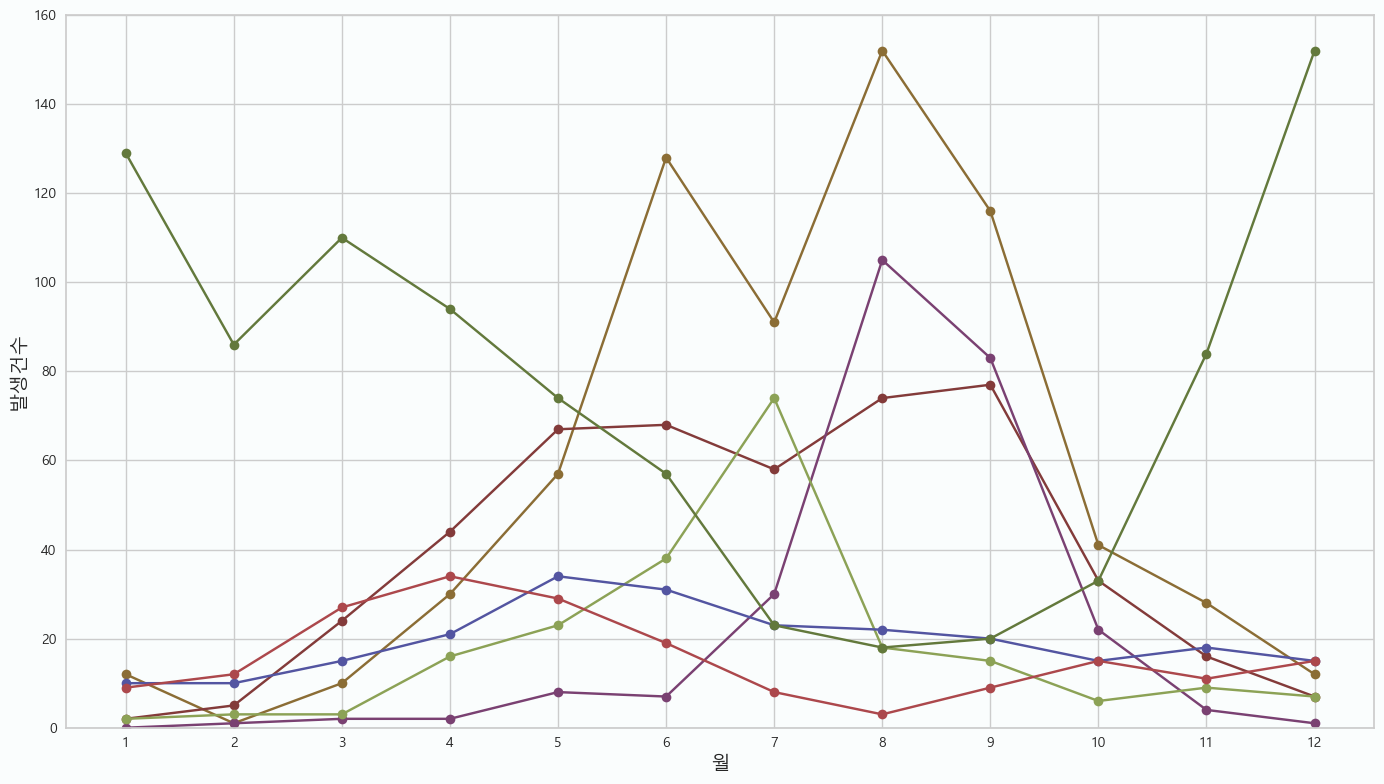

In [71]:
selected_pathogens = [
    '노로바이러스','병원성대장균','살모넬라','장염비브리오',
    '황색포도상구균','캠필로박터제주니','원충','클로스트리디움퍼프린젠스','바실러스세레우스'
    ]

cause_df2 = cause_df[cause_df['OCCRNC_VIRS'].isin(pathogen_list)]

# 월별 원인물질별 발생 건수 추이
monthly_trend = cause_df2.groupby(['OCCRNC_MM', 'OCCRNC_VIRS'])['OCCRNC_CNT'].sum().unstack()

colors = {
    '노로바이러스': '#63793C',
    '병원성대장균': '#8B6D35',
    '살모넬라': '#833B3A',
    '장염비브리오': '#7A4172',
    '황색포도상구균': '#5355A1',
    '캠필로박터제주니': '#8CA256',
    '원충': '#BC9D40',
    '클로스트리디움퍼프린젠스': '#AC484C',
    '바실러스세레우스': '#A45193'
}


# 월별 발생 건수 그래프
plt.figure(figsize=(14, 8))
plt.gcf().patch.set_facecolor('#FAFDFD')

for pathogen in pathogen_list:
    plt.plot(
        monthly_trend.index,  # 월
        monthly_trend[pathogen],  # 각 월별 발생 건수
        marker='o',
        label=pathogen,
        color=colors[pathogen]  # 해당 항목의 색상 지정
    )

# y축 범위와 tick 설정
plt.ylim(0, 160)  # y축 범위 설정
plt.yticks(range(0, 161, 20))  # y축 tick 단위 설정

plt.xticks(range(1, 13, 1))  # 1부터 12까지 1 단위로 설정 (1월부터 12월까지)

#plt.title('원인물질별 월별 발생 건수 추이', fontsize=16)
plt.xlabel('월', fontsize=14)
plt.ylabel('발생건수', fontsize=14)

# Consistent legend placement
#plt.legend(title='원인물질', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(True)
plt.gca().set_facecolor('#FAFDFD')

plt.tight_layout()
plt.show()

#### 2) 2002~2023 월 평균 발생건수

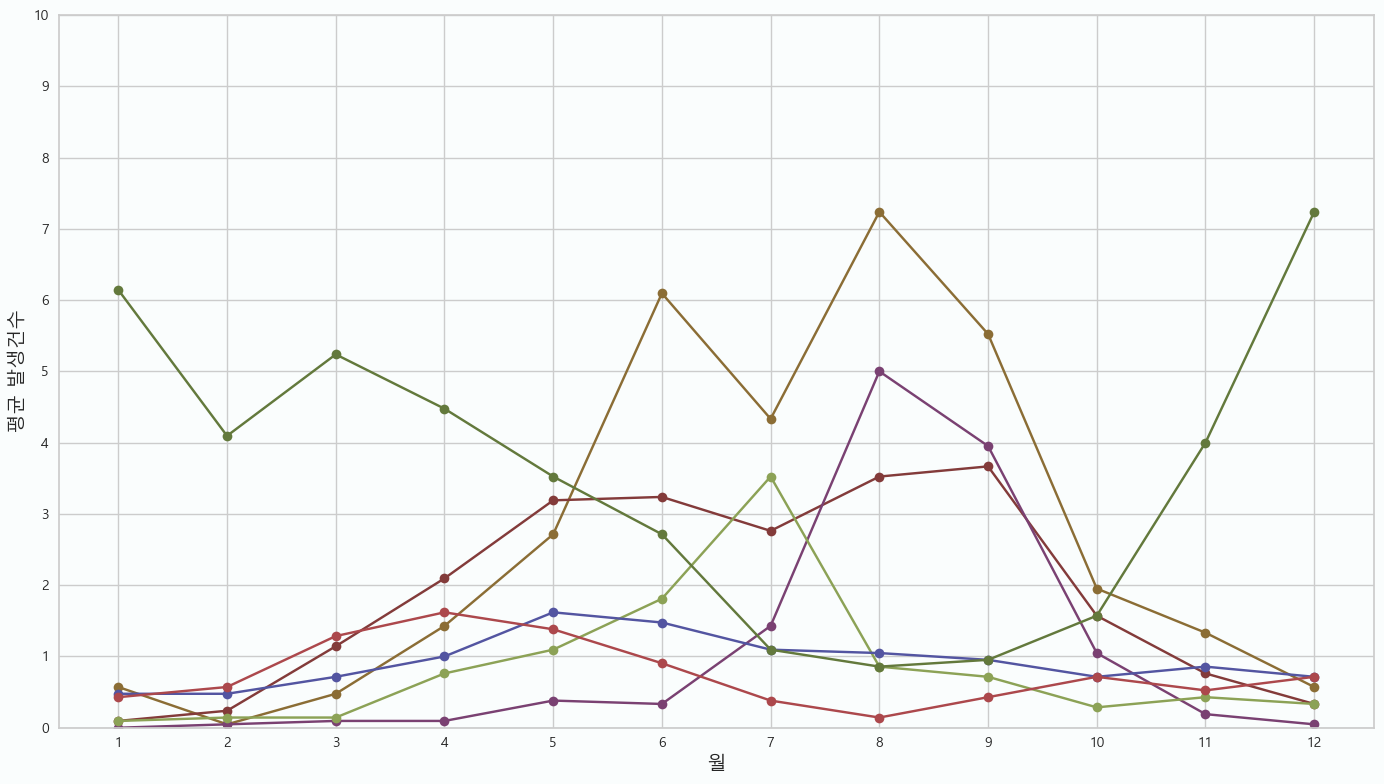

In [72]:
selected_pathogens = [
    '노로바이러스','병원성대장균','살모넬라','장염비브리오',
    '황색포도상구균','캠필로박터제주니','원충','클로스트리디움퍼프린젠스','바실러스세레우스'
    ]

cause_df2 = cause_df[cause_df['OCCRNC_VIRS'].isin(pathogen_list)]

# 월별 원인물질별 발생 건수 추이
monthly_trend = cause_df2.groupby(['OCCRNC_MM', 'OCCRNC_VIRS'])['OCCRNC_CNT'].mean().unstack()

colors = {
    '노로바이러스': '#63793C',
    '병원성대장균': '#8B6D35',
    '살모넬라': '#833B3A',
    '장염비브리오': '#7A4172',
    '황색포도상구균': '#5355A1',
    '캠필로박터제주니': '#8CA256',
    '원충': '#BC9D40',
    '클로스트리디움퍼프린젠스': '#AC484C',
    '바실러스세레우스': '#A45193'
}

# 월별 발생 건수 그래프
plt.figure(figsize=(14, 8))
plt.gcf().patch.set_facecolor('#FAFDFD')

for pathogen in pathogen_list:
    plt.plot(
        monthly_trend.index,  # 월
        monthly_trend[pathogen],  # 각 월별 발생 건수
        marker='o',
        label=pathogen,
        color=colors[pathogen]  # 해당 항목의 색상 지정
    )

# y축 범위와 tick 설정
plt.ylim(0, 10)  # y축 범위 설정
plt.yticks(range(0, 11, 1))  # y축 tick 단위 설정

plt.xticks(range(1, 13, 1))  # 1부터 12까지 1 단위로 설정 (1월부터 12월까지)

#plt.title('원인물질별 월별 발생 건수 추이', fontsize=16)
plt.xlabel('월', fontsize=14)
plt.ylabel('평균 발생건수', fontsize=14)

# Consistent legend placement
#plt.legend(title='원인물질', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(True)
plt.gca().set_facecolor('#FAFDFD')

plt.tight_layout()
plt.show()

## **3. 지역별 식중독 발생 분석**

### 1. 지역별 식중독 발생건수

In [73]:
def region_analysis_pie(region_df, region_col, occurrence_col):

    region_summary = region_df.groupby(region_col)[[occurrence_col]].sum().sort_values(by=occurrence_col, ascending=False)

    # 데이터 및 비율 계산
    total_occurrences = region_summary[occurrence_col].sum()
    region_summary['percent'] = region_summary[occurrence_col] / total_occurrences * 100

    labels = region_summary.index
    sizes = region_summary[occurrence_col]


    pastel_colors = ['#393C78','#63793C','#8B6D35','#833B3A','#7A4172','#5355A1','#8CA256','#BC9D40','#AC484C','#A45193','#6C6FCD','#B5CF6F','#E6B959','#D4606C','#CD6DBC','#9C9EDC','#CEDB9E','#E6CB96','#E6969D','#DD9ED5']


    fig = go.Figure(
        data=[go.Pie( 
            labels=labels,
            values=sizes,
            hole=0,  
            textinfo='percent+label', 
            insidetextorientation='horizontal', 
            marker=dict(colors=pastel_colors[:len(labels)], line=dict(color='#FAFDFD', width=3)),
            sort=False,
            rotation=90,
            direction='clockwise',
            # direction='counterclockwise',
            showlegend=True
        )]
    )

    fig.update_layout(
        # title={
        #     'text': "지역별 식중독 발생 건수 비율",
        #     'x': 0.5,  
        #     'xanchor': 'center',
        #     'yanchor': 'top'
        # },
        #font=dict(size=12, family='Arial', color='black'),
        annotations=[], 
        width=800,  
        height=800,
        paper_bgcolor='#FAFDFD',
        legend=dict(
            font=dict(size=14, family='Arial', weight='bold')
        )
    )

    textfont=dict(size=12, family='Arial', weight='bold'),   # 안쪽 텍스트 (퍼센트+레이블)
    outsidetextfont=dict(size=14, family='Arial', weight='bold')  # 바깥 텍스트 (레이블)

    fig.show()


In [74]:
region_analysis_pie(region_df, 'OCCRNC_REGN', 'OCCRNC_CNT')

### 2. 연도별 발생 건수

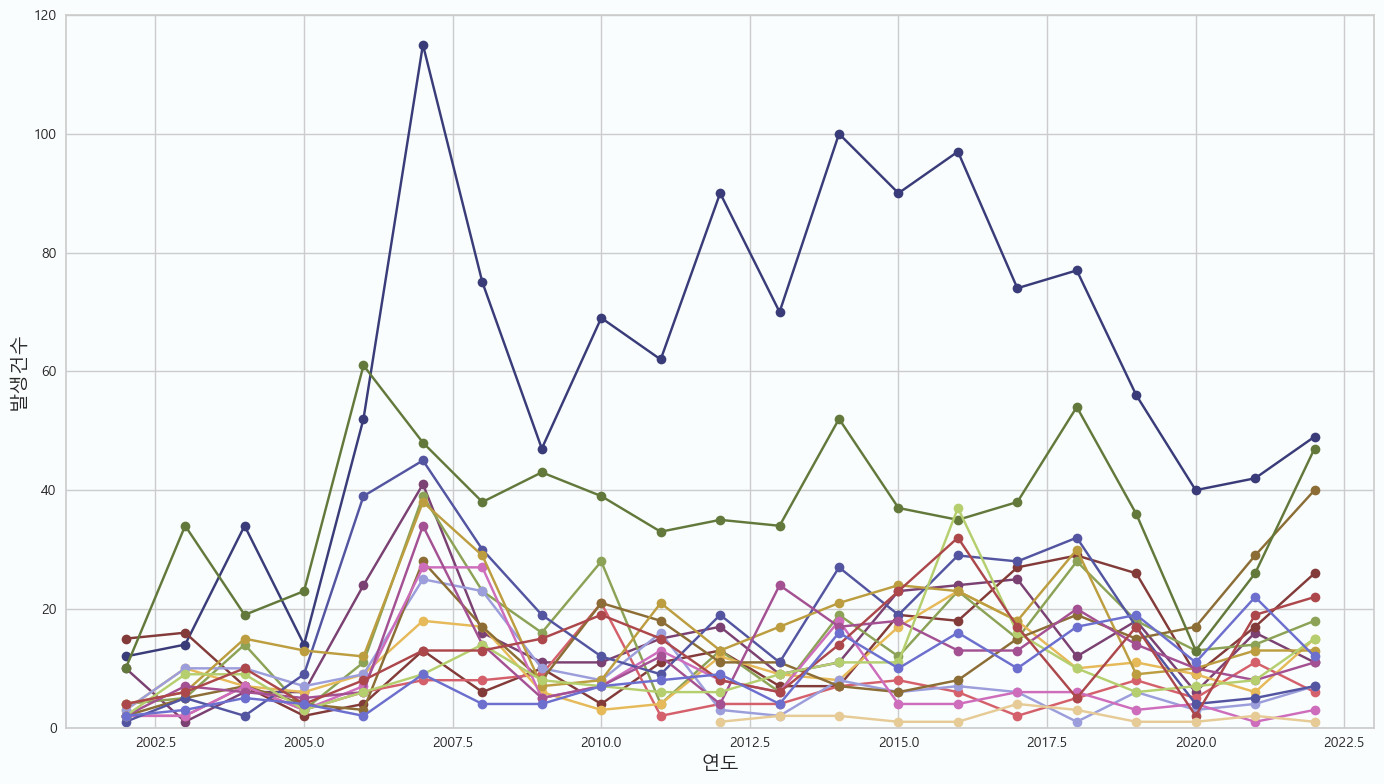

In [75]:
yearly_region_summary = region_df.groupby(['OCCRNC_YEAR', 'OCCRNC_REGN']).agg({'OCCRNC_CNT': 'sum', 'PATNT_CNT': 'sum'}).reset_index()

colors = {
    '경기' : '#393C78', '서울' : '#63793C', 
    '부산' : '#8B6D35', '경남' : '#833B3A', 
    '강원' : '#7A4172', '인천' : '#5355A1', 
    '경북' : '#8CA256', '전남' : '#BC9D40', 
    '충남' : '#AC484C', '전북' : '#A45193', 
    '충북' : '#6C6FCD', '제주' : '#B5CF6F', 
    '대구' : '#E6B959', '광주' : '#D4606C', 
    '울산' : '#CD6DBC', '대전' : '#9C9EDC', 
    '불명' : '#CEDB9E', '세종' : '#E6CB96'
    }


plt.figure(figsize=(14, 8))
plt.gcf().patch.set_facecolor('#FAFDFD')        # 그래프 외부 배경 색상 설정

for region in yearly_region_summary['OCCRNC_REGN'].unique():
    region_data = yearly_region_summary[yearly_region_summary['OCCRNC_REGN'] == region]
    plt.plot(
        region_data['OCCRNC_YEAR'], 
        region_data['OCCRNC_CNT'], 
        marker='o', 
        label=region,
        color=colors.get(region, '#000000') 
    )

#plt.title('연도별 지역별 발생 건수 변화')
plt.xlabel('연도', fontsize=14)
plt.ylabel('발생건수', fontsize=14)

#plt.legend(title='지역별', loc='upper left')
plt.grid(True)

# 그래프 안쪽 배경 색상 설정
plt.gca().set_facecolor('#FAFDFD')

# y축 범위와 tick 설정
plt.ylim(0, 120)  # y축 범위 설정
plt.yticks(range(0, 121, 20))  # y축 tick 단위 설정

plt.tight_layout()
plt.show()


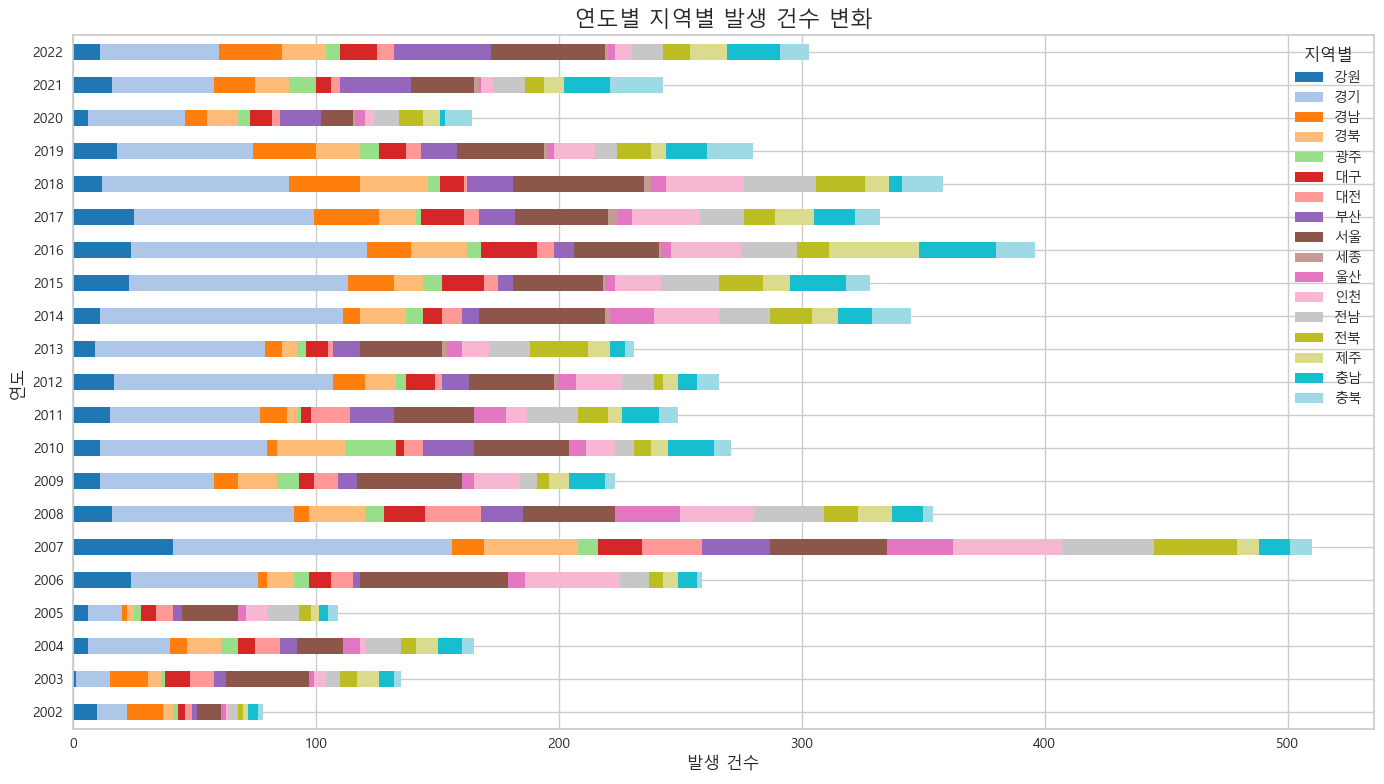

In [76]:
# yearly_facility_summary 데이터를 pivot 형태로 변환 (index는 연도, columns는 지역, values는 발생 건수)
pivot_data = yearly_region_summary.pivot_table(index='OCCRNC_YEAR', columns='OCCRNC_REGN', values='OCCRNC_CNT', aggfunc='sum')

pivot_data.plot(kind='barh', stacked=True, figsize=(14, 8), cmap='tab20')

plt.title('연도별 지역별 발생 건수 변화', fontsize=16)
plt.xlabel('발생 건수', fontsize=12)
plt.ylabel('연도', fontsize=12)
plt.legend(title='지역별', fontsize='small', title_fontsize='medium')
plt.tight_layout()
plt.show()


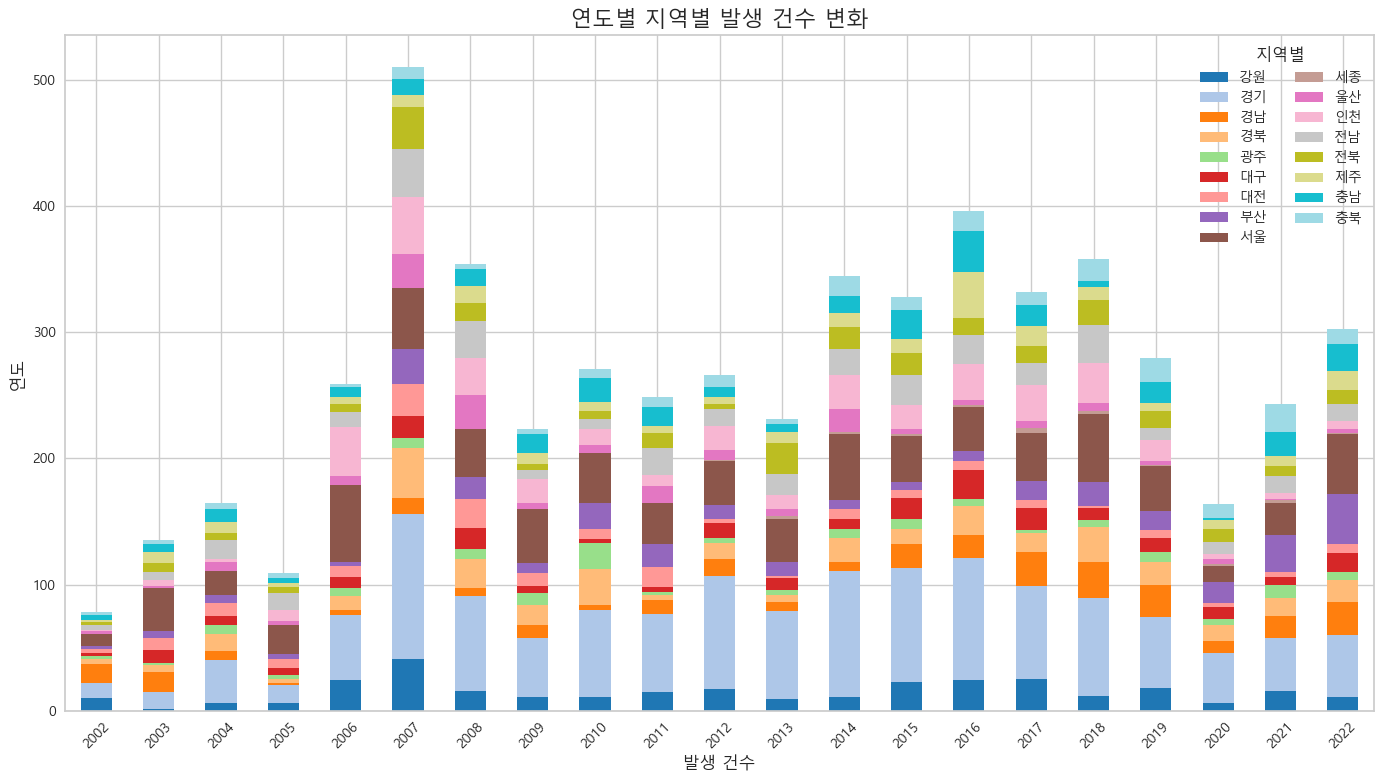

In [77]:
pivot_data = yearly_region_summary.pivot_table(index='OCCRNC_YEAR', columns='OCCRNC_REGN', values='OCCRNC_CNT', aggfunc='sum')

pivot_data.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='tab20')

plt.title('연도별 지역별 발생 건수 변화', fontsize=16)
plt.xlabel('발생 건수', fontsize=12)
plt.ylabel('연도', fontsize=12)
plt.legend(title='지역별', fontsize='small', title_fontsize='medium', ncol=2)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
